# 01 · Data, EDA & Leakage-Safe Split
**Phishing E-mail Detection: A Leakage-Controlled Benchmark of Classical, Deep and Transformer Models**  
*Parts I-II · Sections 1-6* · MSc Data Science final project · Dr. Spoorthi H S

**In this notebook**
- Loads 81,892 e-mails pooled from 6 public corpora (47.9% legitimate / 52.1% phishing)
- EDA: class balance, per-source label purity, length and stylistic signals, Mann-Whitney U test, SVD projection
- Leakage audit: exact and near-duplicate (TF-IDF cosine >= 0.95) template clustering
- Grouped 70/15/15 split (58,280 / 11,503 / 12,109) - no template crosses splits
- Placeholder-based text cleaning and 11 documented stylometric features

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline on a Kaggle Tesla T4 GPU. Every part builds on objects created earlier (the leak-free split, fitted models and their predictions), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[Model Development, Benchmark & Ensembles →](02_model_development_and_ensembles.ipynb)

---

In [1]:
# =====================================================================================
#  EDIT ME  --  project details & display settings
#  Change the values below, then re-run THIS cell and the next one (title page).
#  Nothing else in the notebook needs to be touched: the title page updates itself.
# =====================================================================================

# ---- Title (edit freely) -------------------------------------------------------------
PROJECT_TITLE    = "Beyond Accuracy"
PROJECT_SUBTITLE = ("A Robustness-First Benchmark of Classical, Transformer and Hybrid "
                    "Models for Phishing-Email Detection")

# ---- Student & programme details (edit these) ------------------------------------------
STUDENT_NAME    = "[Your Full Name]"
STUDENT_ID      = "[Your Student ID]"
PROGRAMME       = "MSc [Programme Name]"
MODULE          = "[Module Code - Module Title]"
SUPERVISOR      = "[Supervisor Name]"
INSTITUTION     = "[Institution Name]"
SUBMISSION_DATE = "[DD Month YYYY]"

# ---- Display settings ------------------------------------------------------------------
BASE_FONT_PX = 17          # size of notebook text (markdown, tables). Jupyter's default is ~14.
CODE_FONT_PX = 14          # size of code and printed output.
PLOT_FONT_PT = 12          # base font size of every chart (titles/labels scale from this).
ACCENT_COLOR = "#1D3557"   # colour of the title-page banner and part banners.


In [2]:
# Title page + notebook typography (presentation only). Reads the values from the previous cell.
from IPython.display import HTML, display
import html as _html

def _e(x):
    return _html.escape(str(x))

_css = f"""
<style>
  /* Notebook typography -- controlled by BASE_FONT_PX / CODE_FONT_PX above */
  .jp-RenderedHTMLCommon, .jp-RenderedMarkdown, .text_cell_render, .rendered_html {{
      font-size: {BASE_FONT_PX}px !important; line-height: 1.6 !important; }}
  .jp-RenderedHTMLCommon table, .rendered_html table, .text_cell_render table {{
      font-size: {max(BASE_FONT_PX - 2, 10)}px !important; }}
  .jp-RenderedHTMLCommon th, .rendered_html th {{ background: rgba(29,53,87,.10); }}
  .jp-RenderedHTMLCommon h2, .rendered_html h2, .text_cell_render h2 {{
      border-bottom: 3px solid {ACCENT_COLOR}; padding-bottom: .2em; margin-top: 1.6em; }}
  .jp-RenderedHTMLCommon h3, .rendered_html h3, .text_cell_render h3 {{ color: {ACCENT_COLOR}; }}
  .jp-RenderedHTMLCommon blockquote, .rendered_html blockquote {{
      border-left: 5px solid {ACCENT_COLOR}; background: rgba(29,53,87,.05);
      padding: .5em 1em; border-radius: 0 6px 6px 0; }}
  .CodeMirror, .cm-editor, .jp-InputArea-editor, .CodeMirror pre {{ font-size: {CODE_FONT_PX}px !important; }}
  .jp-OutputArea-output pre, .output_area pre, .output_text pre {{ font-size: {max(CODE_FONT_PX - 1, 10)}px !important; }}
</style>
"""

_rows = [("Author", STUDENT_NAME), ("Student ID", STUDENT_ID), ("Programme", PROGRAMME),
         ("Module", MODULE), ("Supervisor", SUPERVISOR), ("Institution", INSTITUTION),
         ("Submission date", SUBMISSION_DATE)]
_rows_html = "".join(f"<tr><td style='padding:2px 14px 2px 0;opacity:.85'><b>{_e(k)}</b></td>"
                     f"<td style='padding:2px 0'>{_e(v)}</td></tr>" for k, v in _rows)

_title_html = f"""
{_css}
<div style="background:{ACCENT_COLOR};color:#fff;padding:34px 40px;border-radius:14px;margin:6px 0 18px 0">
  <div style="font-size:0.8em;letter-spacing:.18em;text-transform:uppercase;opacity:.8">Master's Dissertation</div>
  <div style="font-size:2.1em;font-weight:800;line-height:1.25;margin-top:4px">{_e(PROJECT_TITLE)}</div>
  <div style="font-size:1.15em;opacity:.94;margin-top:8px;max-width:900px">{_e(PROJECT_SUBTITLE)}</div>
  <table style="margin-top:22px;font-size:0.95em">{_rows_html}</table>
</div>
"""
display(HTML(_title_html))


Author,[Your Full Name]
Student ID,[Your Student ID]
Programme,MSc [Programme Name]
Module,[Module Code - Module Title]
Supervisor,[Supervisor Name]
Institution,[Institution Name]
Submission date,[DD Month YYYY]


## Abstract

Phishing e-mail remains one of the most common initial-access vectors in cyber attacks, and automated text
classification is a standard line of defence. This study builds and rigorously compares **six candidate models from
three families** and carries **five finalists** into the final benchmark: two tuned classical baselines
(TF-IDF + Logistic Regression and TF-IDF + Linear SVM), two fine-tuned Transformers (DistilBERT and RoBERTa-base) and a
custom Attention-BiGRU fused with hand-crafted stylometric features. A BiLSTM was a candidate but was not among the
top two baselines. All models are trained and scored on one leakage-audited, grouped train/validation/test split of
**N = 81,892 e-mails** pooled from six public corpora (CEAS-08, Enron, Ling, Nazario, Nigerian Fraud and a residual
"unknown" source).

In the run captured in this notebook (Kaggle GPU runtime, Tesla T4, `QUICK_RUN = False`), **RoBERTa-base** has the
highest **validation F1 (0.9931)** and is therefore the selected model. On the held-out test set it reaches
**F1 = 0.9943** (95% bootstrap CI 0.9929-0.9956) and **ROC-AUC = 0.9997**. DistilBERT scores fractionally higher on
test (F1 = 0.9948), but the gap is not statistically significant (paired bootstrap p = 0.50, Section 13): the two
Transformers are practically tied. Both are ahead of TF-IDF + Linear SVM (F1 = 0.988), the out-of-fold stacked
ensemble of the two classical baselines (0.987), TF-IDF + Logistic Regression (0.985) and the custom hybrid (0.984).
Beyond headline accuracy the notebook reports probability calibration, a cost-aware decision threshold,
leave-one-source-out generalisation, obfuscation robustness with a normalisation defence, architecture and feature
ablations, and explainability (SHAP and Integrated Gradients), so the comparison speaks to *robustness and
deployability*, not only in-distribution accuracy.

**Data caveat.** The pooled corpora are largely older spam and legitimate-mail collections, and two sources (Nigerian
Fraud, Nazario) are 100% phishing. In-distribution F1 near 0.994 should therefore be read next to the
leave-one-source-out result (F1 = 0.82-0.88 for TF-IDF + Logistic Regression, Section 20), which shows partial
reliance on source-specific patterns.

**Scope note.** Sections 17, 22 and 25 (social-engineering tactic detection, the RAG explanation demo and the
LangGraph SOC agent) are engineering extensions built on the benchmark; they are evaluated separately and less
exhaustively than the core model comparison (see the scope note that opens each of them).

**Keywords:** phishing detection, NLP, TF-IDF, Transformers, BiGRU, ensemble learning, data leakage, model
calibration, ablation study, cross-domain generalisation, adversarial robustness, explainable AI.

---

> **Reproducibility note.** This notebook is written to be run **top to bottom, once, on a
> single kernel** (`Kernel → Restart & Run All`). Section 1 exposes the run-mode switches
> (`QUICK_RUN`, `RUN_TRANSFORMERS`, `RUN_HP_SEARCH`, `RUN_SHAP`, `RUN_IG`, `RUN_DEPLOYMENT_ARTIFACTS`)
> that control which optional/expensive stages execute. The full run (as reported in the
> Abstract) needs a GPU (Tesla T4 or better) and internet access to the Hugging Face Hub for
> Section 9; a CPU-only `QUICK_RUN = True` pass is provided for a fast structural/logic check
> and is **not** the run the reported numbers come from. See Appendix A for the full change log.


In [3]:
# Presentation helpers: chart theme, colour palette, figure captions and flowchart primitives.
# (Presentation only -- no modelling logic lives here.)
import textwrap
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon
from matplotlib.font_manager import FontProperties

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

# ---- Palette (colour-blind-aware, consistent across the whole notebook) -------------------
C_LEGIT  = "#2A6F97"   # legitimate class / classical models
C_PHISH  = "#D1495B"   # phishing class / warnings
C_TEAL   = "#2A9D8F"   # positive / selected
C_AMBER  = "#E9A23B"   # highlight / caution
C_SLATE  = "#33415C"   # text
C_PURPLE = "#6D597A"   # custom / hybrid model
C_GREY   = "#8D99AE"   # neutral / excluded
C_LIGHT  = "#EEF2F7"   # light panel background
C_NAVY   = globals().get("ACCENT_COLOR", "#1D3557")

FAMILY_COLORS = {"classical": C_LEGIT, "deep": C_PURPLE, "transformer": C_PHISH,
                 "custom": C_AMBER, "ensemble": C_TEAL}

def model_color(name):
    n = str(name).lower()
    if "distil" in n or "roberta" in n or "lora" in n: return FAMILY_COLORS["transformer"]
    if "custom" in n or "gru" in n:                    return FAMILY_COLORS["custom"]
    if "stack" in n or "ensemble" in n:                return FAMILY_COLORS["ensemble"]
    if "lstm" in n:                                    return FAMILY_COLORS["deep"]
    return FAMILY_COLORS["classical"]

mpl.rcParams.update({
    "font.size": globals().get("PLOT_FONT_PT", 12),
    "axes.titlesize": globals().get("PLOT_FONT_PT", 12) + 2,
    "axes.labelsize": globals().get("PLOT_FONT_PT", 12),
    "figure.facecolor": "white",
    "axes.edgecolor": C_SLATE,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# NOTE (bugfix, Figures 0.1 & 0.2): these three helpers used to have two bugs that combined
# into completely garbled figures:
#   1. `flow_canvas` sized the figure as (w/8.0, h/8.0) inches. For Figure 0.1 (w=17.5) that is
#      a ~2-inch-wide canvas; every box/label was still drawn at its normal font size on that
#      tiny canvas, so titles, column headers and box text all piled on top of each other.
#      Figure 0.2 was worse: its box coordinates go out to x=184, y=85, but it was called as
#      `flow_canvas(17.5, 9.6, ...)` -- an axis range 10x too small for its own content. Every
#      box (clipped to the axes) was invisible; only the unclipped text remained, scattered
#      across a huge auto-cropped canvas.
#   2. `flow_box` never wrapped its text to the box width (the `textwrap` import was unused),
#      so any label longer than a couple of words spilled out of its box and into its
#      neighbours regardless of canvas size.
# The fix below (a) sizes the figure from a fixed target width and the *aspect ratio* of the
# content, so it no longer matters what "unit scale" a particular figure's coordinates happen
# to use, and (b) actually wraps box text to fit, using the axes' real data-to-pixel scale.
_FLOW_TARGET_WIDTH_IN = 14.0

def flow_canvas(w, h, title, subtitle=None):
    total_h = h + 6  # extra headroom for the title/subtitle text drawn above the content
    fig_w_in = _FLOW_TARGET_WIDTH_IN
    fig_h_in = _FLOW_TARGET_WIDTH_IN * (total_h / w)
    fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))
    ax.set_xlim(0, w); ax.set_ylim(0, total_h)
    ax.axis("off")
    ax.text(0, h + 4, title, fontsize=mpl.rcParams["font.size"] + 3, fontweight="bold", color=C_NAVY)
    if subtitle:
        ax.text(0, h + 1.6, subtitle, fontsize=mpl.rcParams["font.size"] - 1, color=C_GREY, style="italic")
    return fig, ax

def _data_per_point(ax):
    """(x_data_per_point, y_data_per_point): how many data units one point (1/72 inch)
    covers along each axis, given the axes' current on-screen size. Lets us convert a
    font size in points into a width/height in the same data units used for box layout."""
    fig = ax.figure
    bbox = ax.get_position()
    fig_w_in, fig_h_in = fig.get_size_inches()
    axes_w_pt = bbox.width * fig_w_in * 72.0
    axes_h_pt = bbox.height * fig_h_in * 72.0
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    x_per_pt = (xlim[1] - xlim[0]) / axes_w_pt
    y_per_pt = (ylim[1] - ylim[0]) / axes_h_pt
    return x_per_pt, y_per_pt

def wrap_flow_text(ax, text, max_width_data, fontsize):
    """Wrap `text` (word-wrapping each existing line separately, so explicit '\\n's in a
    label are preserved) so that every rendered line fits within `max_width_data` data
    units at the given font size. Uses the renderer's own text-measurement, so it accounts
    for the actual font rather than a rough character-count guess."""
    fig = ax.figure
    canvas = fig.canvas
    if not hasattr(canvas, "get_renderer"):
        canvas.draw()
    renderer = canvas.get_renderer() if hasattr(canvas, "get_renderer") else canvas.get_renderer()
    prop = FontProperties(size=fontsize)
    x_per_pt, _ = _data_per_point(ax)
    max_width_pt = max_width_data / x_per_pt if x_per_pt > 0 else float("inf")

    def width_pt(s):
        w_px, _, _ = renderer.get_text_width_height_descent(s, prop, ismath=False)
        # Agg renderer reports widths in *pixels* at the figure's dpi; convert to points.
        return w_px * 72.0 / fig.dpi

    out_lines = []
    for paragraph in str(text).split("\n"):
        words = paragraph.split(" ")
        if not words or words == [""]:
            out_lines.append("")
            continue
        cur = words[0]
        for word in words[1:]:
            trial = cur + " " + word
            if width_pt(trial) <= max_width_pt:
                cur = trial
            else:
                out_lines.append(cur)
                cur = word
        out_lines.append(cur)
    return "\n".join(out_lines)

def flow_text_height(ax, text, max_width_data, fontsize, linespacing=1.35, vpad=1.4):
    """Data-unit box height needed to fit `text` (after wrapping to max_width_data) at
    the given font size, so callers can size a box before drawing it."""
    wrapped = wrap_flow_text(ax, text, max_width_data, fontsize)
    n_lines = wrapped.count("\n") + 1
    _, y_per_pt = _data_per_point(ax)
    line_height_data = fontsize * linespacing * y_per_pt
    return n_lines * line_height_data + vpad

def flow_box(ax, x, y, w, h, text, fc="white", ec=None, tc=None, fs=None, lw=1.8, bold=False, ls="-"):
    ec = ec or C_SLATE; tc = tc or C_SLATE
    fs = fs or mpl.rcParams["font.size"]
    # Proportional corner rounding: the old hardcoded pad=0.6/rounding_size=3 was tuned for
    # Figure 0.2's large boxes (width 30-42) and rendered as a crossed circle on Figure 0.1's
    # narrow columns (width ~2.1), where the "rounding" was bigger than the box itself.
    pad = max(0.04, min(w, h) * 0.05)
    rounding_size = max(0.08, min(w, h) * 0.12)
    box = FancyBboxPatch((x + pad, y + pad), w - 2 * pad, h - 2 * pad,
                          boxstyle=f"round,pad={pad},rounding_size={rounding_size}",
                          fc=fc, ec=ec, lw=lw, linestyle=ls)
    ax.add_patch(box)
    wrapped = wrap_flow_text(ax, text, w * 0.9, fs)
    ax.text(x + w / 2, y + h / 2, wrapped, ha="center", va="center", fontsize=fs,
            color=tc, fontweight="bold" if bold else "normal", linespacing=1.35)
    return {"l": (x, y + h / 2), "r": (x + w, y + h / 2), "t": (x + w / 2, y + h),
            "b": (x + w / 2, y), "x": x, "y": y + h / 2, "w": w, "h": h}

def flow_arrow(ax, p1, p2, color=C_SLATE, lw=1.8, ls="-", rad=0.0):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=14,
                                  color=color, lw=lw, linestyle=ls,
                                  connectionstyle=f"arc3,rad={rad}"))


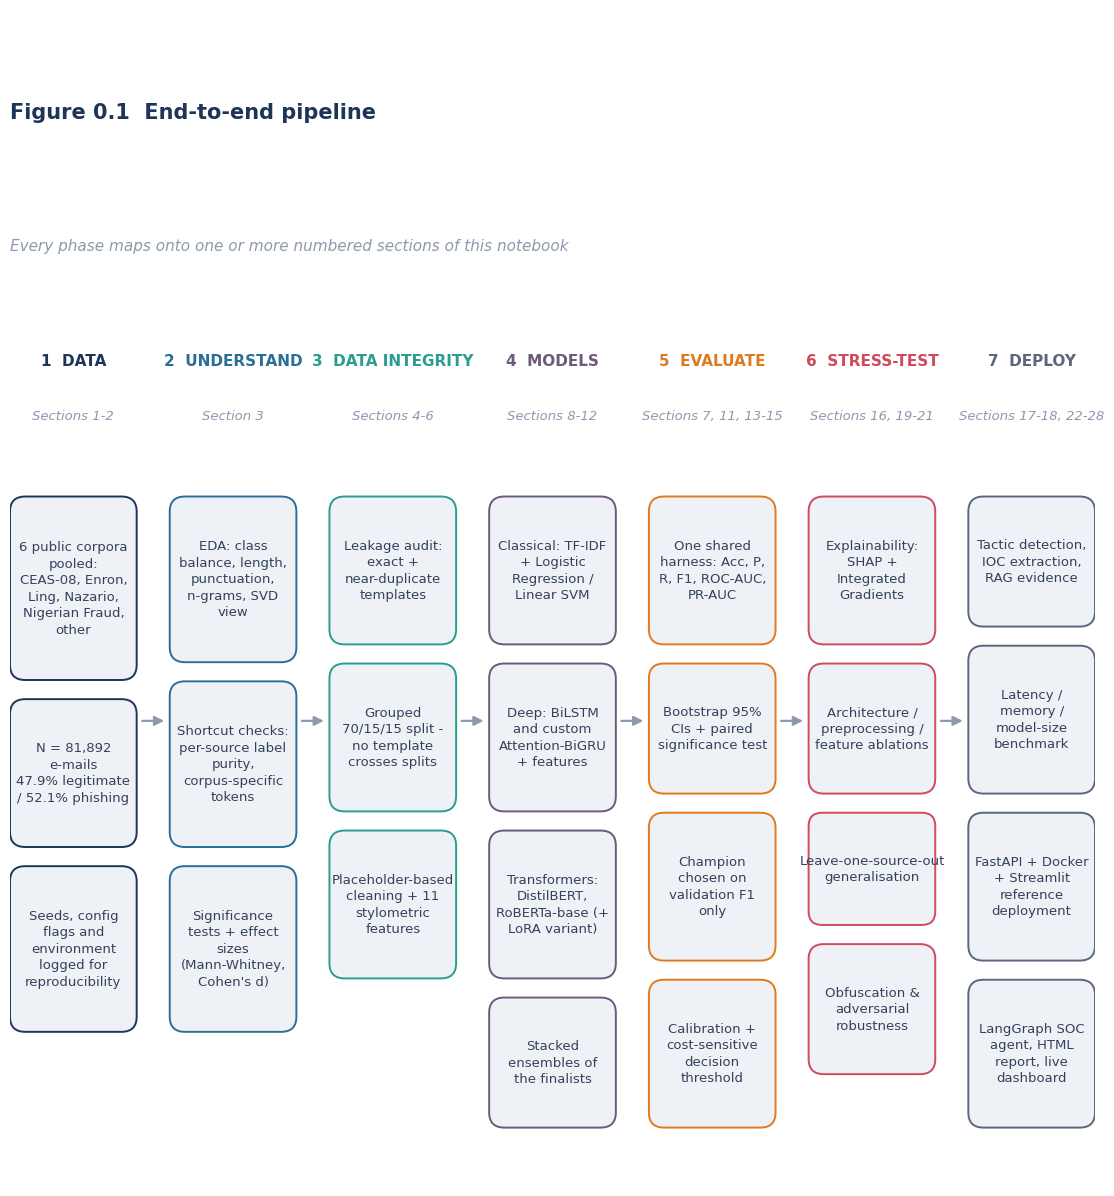

In [4]:
# Figure 0.1 -- end-to-end pipeline (presentation only)
_phases = [
    dict(name="1  DATA", sec="Sections 1-2", color="#1D3557", items=[
        "6 public corpora pooled: CEAS-08, Enron, Ling, Nazario, Nigerian Fraud, other",
        "N = 81,892 e-mails\n47.9% legitimate / 52.1% phishing",
        "Seeds, config flags and environment logged for reproducibility"]),
    dict(name="2  UNDERSTAND", sec="Section 3", color="#2A6F97", items=[
        "EDA: class balance, length, punctuation, n-grams, SVD view",
        "Shortcut checks: per-source label purity, corpus-specific tokens",
        "Significance tests + effect sizes (Mann-Whitney, Cohen's d)"]),
    dict(name="3  DATA INTEGRITY", sec="Sections 4-6", color="#2A9D8F", items=[
        "Leakage audit: exact + near-duplicate templates",
        "Grouped 70/15/15 split - no template crosses splits",
        "Placeholder-based cleaning + 11 stylometric features"]),
    dict(name="4  MODELS", sec="Sections 8-12", color="#6D597A", items=[
        "Classical: TF-IDF + Logistic Regression / Linear SVM",
        "Deep: BiLSTM and custom Attention-BiGRU + features",
        "Transformers: DistilBERT, RoBERTa-base (+ LoRA variant)",
        "Stacked ensembles of the finalists"]),
    dict(name="5  EVALUATE", sec="Sections 7, 11, 13-15", color="#E07A1F", items=[
        "One shared harness: Acc, P, R, F1, ROC-AUC, PR-AUC",
        "Bootstrap 95% CIs + paired significance test",
        "Champion chosen on validation F1 only",
        "Calibration + cost-sensitive decision threshold"]),
    dict(name="6  STRESS-TEST", sec="Sections 16, 19-21", color="#D1495B", items=[
        "Explainability: SHAP + Integrated Gradients",
        "Architecture / preprocessing / feature ablations",
        "Leave-one-source-out generalisation",
        "Obfuscation & adversarial robustness"]),
    dict(name="7  DEPLOY", sec="Sections 17-18, 22-28", color="#5C677D", items=[
        "Tactic detection, IOC extraction, RAG evidence",
        "Latency / memory / model-size benchmark",
        "FastAPI + Docker + Streamlit reference deployment",
        "LangGraph SOC agent, HTML report, live dashboard"]),
]
n = len(_phases)
gap = 0.6
col_w = 2.3
# NOTE (bugfix): the canvas width passed to flow_canvas used to be a fixed 17.5, while the
# column width below was computed as 15.5 / n (15.5 is this figure's *height*, not its
# width -- a copy-paste slip). For n=7 columns that put the last column's right edge at
# x=19.1, past the declared 17.5-wide canvas, so it was silently clipped off. The canvas
# width is now derived from the same column layout it has to contain, so they can never
# drift apart again.
total_w = n * col_w + (n - 1) * gap
fig, ax = flow_canvas(total_w, 15.5, "Figure 0.1  End-to-end pipeline",
                      "Every phase maps onto one or more numbered sections of this notebook")
for i, ph in enumerate(_phases):
    x = i * (col_w + gap)
    ax.text(x + col_w / 2, 15.0, ph["name"], ha="center", fontsize=mpl.rcParams["font.size"] - 1,
            fontweight="bold", color=ph["color"])
    ax.text(x + col_w / 2, 14.0, ph["sec"], ha="center", fontsize=mpl.rcParams["font.size"] - 2.5,
            color=C_GREY, style="italic")
    y = 12.6
    for item in ph["items"]:
        item_fs = mpl.rcParams["font.size"] - 2.5
        # NOTE (bugfix): height used to be guessed from the *un-wrapped* newline count
        # ("2.1 + 0.5 * item.count(chr(10))"), which ignored the extra line breaks that
        # word-wrapping introduces for long items -- boxes were then too short and their
        # text spilled into the box above/below. Ask flow_text_height for the height the
        # wrapped text will actually need at this font size, so the box always fits it.
        h = flow_text_height(ax, item, col_w * 0.9, item_fs)
        flow_box(ax, x, y - h, col_w, h, item, fc=C_LIGHT, ec=ph["color"], tc=C_SLATE,
                  fs=item_fs, lw=1.4)
        y -= h + 0.35
    if i < n - 1:
        flow_arrow(ax, (x + col_w + 0.05, 8.5), (x + col_w + gap - 0.05, 8.5), color=C_GREY, lw=1.6)
if "WORKING_DIR" in globals():
    fig.savefig(WORKING_DIR / "plots" / "fig_0_1_pipeline.png", dpi=170, bbox_inches="tight")
plt.show()


## About this notebook

Phishing e-mail is still one of the most common ways attackers gain a first foothold, and text classifiers sit at the
heart of most defences. Published scores for such classifiers are usually very high, but a score is only as trustworthy as
the data split, the selection protocol and the stress tests behind it. This notebook is a complete, reproducible study of
how good the best detectors *really* are, what they cost, and where they break.

**What it does, in seven steps** (see Figure 0.1 below):

1. **Loads and profiles** 81,892 e-mails pooled from six public corpora and checks them for shortcuts (Sections 1-3).
2. **Audits and repairs data leakage.** Exact and near-duplicate templates are clustered so that no template can appear in
   more than one of train, validation and test (Section 4).
3. **Prepares text and features** with placeholder-based cleaning and eleven stylometric features (Sections 5-6).
4. **Benchmarks six candidate models in three families** (classical, deep and Transformer), narrows them to five
   finalists on validation F1, and tests ensembles (Sections 7-12; Figure 0.2 shows the funnel).
5. **Evaluates rigorously** with bootstrap confidence intervals, paired significance tests, calibration and a
   cost-sensitive decision threshold (Sections 13-15).
6. **Stress-tests trust** through explainability, ablations, leave-one-source-out generalisation and obfuscation attacks
   (Sections 16 and 19-21).
7. **Delivers** analyst-facing extensions (social-engineering tactics, indicators of compromise, retrieval-grounded
   explanations and a LangGraph SOC agent), an efficiency benchmark and a FastAPI / Docker / Streamlit reference
   deployment (Sections 17-18 and 22-28).

### Headline findings (captured Kaggle T4 run)

- **Transformers win, modestly.** RoBERTa-base (selected on validation F1 = 0.9931) and DistilBERT reach test F1 of 0.9943
  and 0.9948, against 0.988 for the best classical model - roughly half as many mistakes on 12,109 test e-mails - but the
  two Transformers cannot be told apart statistically (p = 0.50).
- **The gain is expensive.** Fine-tuning took about 38 and 80 minutes, against 6-8 seconds for the TF-IDF models, and
  batched inference is about 34x slower (14.3 vs 0.42 ms per e-mail).
- **A purpose-built architecture did not pay off.** The custom Attention-BiGRU + features model was the weakest finalist
  (F1 = 0.984), and its ablations show no measurable benefit from attention pooling or engineered features.
- **In-distribution scores flatter the models.** F1 falls from 0.986 to 0.82-0.88 when a whole source corpus is held out,
  and corpus identifiers such as `enron` are among the most influential tokens.
- **Obfuscation is the weak spot, and fixable.** Leetspeak, homoglyphs and whitespace injection together cut RoBERTa's F1
  from 0.992 to 0.673; a character-normalisation defence recovers it to 0.824 (homoglyphs fully, to 0.992).
- **Cost-aware thresholds matter.** With a missed phishing e-mail assumed to cost 25x a false alarm, the cost-optimal
  threshold cuts expected validation cost by 20.2% and test misses from 42 to 23.

### How to read and run this notebook

- The 28 numbered sections are grouped into **Parts I-IX**. Each part banner lists the research questions (RQ1-RQ8) it
  addresses, and figure numbers follow section numbers (Figure 4.1 sits in Section 4).
- Blocks starting with **Interpretation** explain each result and quote numbers from the outputs directly above them.
- To reproduce the study: use a Kaggle GPU runtime (Tesla T4) with Internet enabled and **Run All**. The master switches
  are in Section 1 (`QUICK_RUN = True` gives a fast smoke test).
- **To personalise the notebook**, edit the first code cell (title, name, student ID, programme, supervisor, date, font
  sizes) and re-run it together with the title-page cell.

## Research Questions

The study is organised around eight research questions. Section 26 answers each of them with evidence from the
sections listed here.

| # | Research question | Where investigated |
|---|---|---|
| **RQ1** | **Accuracy.** Do fine-tuned pretrained Transformers detect phishing e-mails significantly better than tuned classical baselines and a purpose-built custom architecture, when all are evaluated on the same leakage-free split? | Sections 8-11, 13-14 |
| **RQ2** | **Cost.** What does any accuracy gain cost in training time, inference latency, throughput and model size, and does parameter-efficient fine-tuning (LoRA) close the gap? | Sections 9.5, 11, 23 |
| **RQ3** | **Design value.** Do the custom design choices (attention pooling, engineered stylometric features, text cleaning and ensembling) measurably improve detection? | Sections 6, 10, 12, 19 |
| **RQ4** | **Data integrity.** How prevalent are duplicate and near-duplicate templates in the pooled corpora, and how must they be handled for a fair comparison? | Sections 3-4 |
| **RQ5** | **Generalisation.** Do the models learn portable phishing language or corpus-specific shortcuts, and how well do they perform on a source they have never seen? | Sections 3.2-3.4, 16, 20 |
| **RQ6** | **Robustness.** How much does the selected model degrade under cheap, realistic obfuscation (leetspeak, homoglyphs, whitespace injection), and can simple normalisation help? | Section 21 |
| **RQ7** | **Decision-making.** Are the predicted probabilities well calibrated, and how should the operating threshold be set when a missed phishing e-mail costs far more than a false alarm? | Section 15 |
| **RQ8** | **Analyst value (exploratory).** Can the classifier's output be turned into analyst-ready evidence (tactics, indicators of compromise, retrieved guidance, risk tier) without letting an LLM override the verdict? | Sections 17-18, 22, 25 |


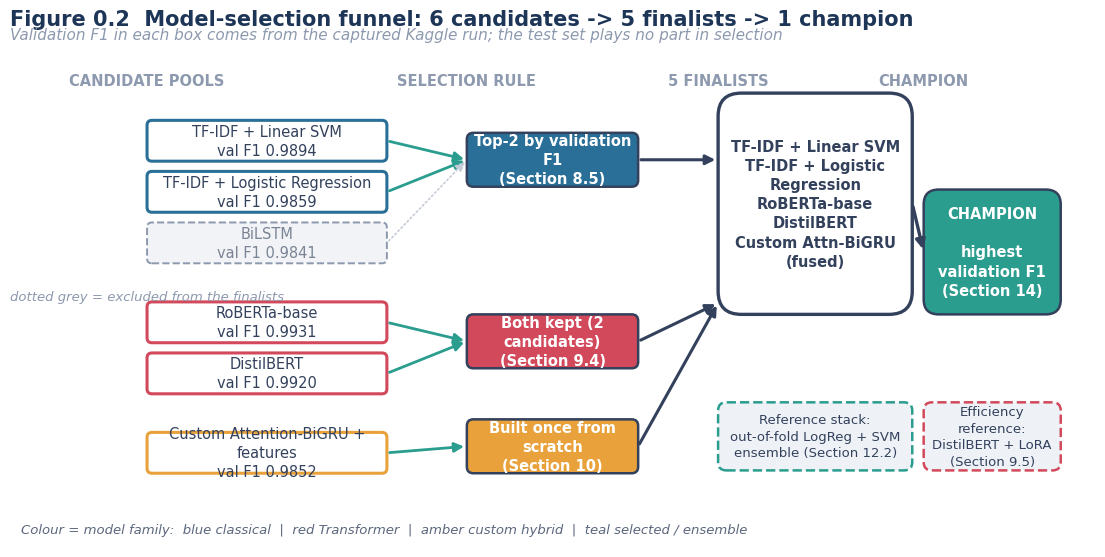

In [5]:
# Figure 0.2 -- from six candidates to one champion (validation F1 values are from the captured run)
# NOTE (bugfix): this used to call flow_canvas(17.5, 9.6, ...), but every coordinate drawn
# below (boxes out to x=184, y=85) uses a completely different, ~10x larger coordinate
# system. The axes limits therefore only covered a small corner of the real layout: every
# box (clipped to the axes) was invisible, and only the unclipped text remained, scattered
# across a huge auto-cropped canvas. flow_canvas's arguments must describe the actual
# extent of the content drawn inside it, so they are corrected to match here.
fig, ax = flow_canvas(190, 88, "Figure 0.2  Model-selection funnel: 6 candidates -> 5 finalists -> 1 champion",
                      "Validation F1 in each box comes from the captured Kaggle run; the test set plays no part in selection")
fs = mpl.rcParams["font.size"] - 1.5
for x, t in [(24, "CANDIDATE POOLS"), (80, "SELECTION RULE"), (124, "5 FINALISTS"), (160, "CHAMPION")]:
    ax.text(x, 81.5, t, ha="center", fontsize=fs, fontweight="bold", color=C_GREY)

cands = [  # (label, family colour, kept?, y)
    ("TF-IDF + Linear SVM\nval F1 0.9894", C_LEGIT, True, 68),
    ("TF-IDF + Logistic Regression\nval F1 0.9859", C_LEGIT, True, 59),
    ("BiLSTM\nval F1 0.9841", C_LEGIT, False, 50),
    ("RoBERTa-base\nval F1 0.9931", C_PHISH, True, 36),
    ("DistilBERT\nval F1 0.9920", C_PHISH, True, 27),
    ("Custom Attention-BiGRU + features\nval F1 0.9852", C_AMBER, True, 13),
]
boxes = []
for lab, col, kept, y in cands:
    b = flow_box(ax, 24, y, 42, 7.2, lab, fc="white" if kept else "#F1F3F6", ec=col if kept else C_GREY,
                 tc=C_SLATE if kept else "#7B8494", fs=fs, lw=2.2 if kept else 1.4, ls="-" if kept else "--")
    boxes.append((b, kept))

gates = [("Top-2 by validation F1\n(Section 8.5)", 63.5, C_LEGIT),
         ("Both kept (2 candidates)\n(Section 9.4)", 31.5, C_PHISH),
         ("Built once from scratch\n(Section 10)", 13, C_AMBER)]
gb = [flow_box(ax, 80, y, 30, 9.5, t, fc=c, tc="white", fs=fs, bold=True) for t, y, c in gates]

groups = [(0, 1, 2, 0), (3, 4, 4, 1), (5, 5, 5, 2)]
for a, b, c, gi in groups:
    for k in range(a, c + 1):
        bx, kept = boxes[k]
        flow_arrow(ax, bx["r"], (gb[gi]["l"][0], gb[gi]["y"]), color=C_TEAL if kept else "#C5CBD6",
                   lw=2.0 if kept else 1.2, ls="-" if kept else ":", rad=0.0)
ax.text(24, 43.6, "dotted grey = excluded from the finalists", fontsize=fs - 1, color=C_GREY, ha="center", style="italic")

fin = flow_box(ax, 124, 41, 34, 39,
               "TF-IDF + Linear SVM\nTF-IDF + Logistic Regression\nRoBERTa-base\nDistilBERT\nCustom Attn-BiGRU (fused)",
               fc="white", ec=C_SLATE, tc=C_SLATE, fs=fs, lw=2.4, bold=True)
for g in gb:
    # NOTE (bugfix): the target y used to be clamped to the hardcoded range [27, 55], which
    # was leftover from an earlier layout -- the "5 finalists" box actually spans y=41 to
    # y=80, so two of the three arrows were clamped to y-values *below* the box entirely and
    # never visibly reached it. Clamp to the box's own (current) vertical span instead.
    target_y = min(max(g["y"], fin["b"][1] + 2), fin["t"][1] - 2)
    flow_arrow(ax, g["r"], (fin["l"][0], target_y), color=C_SLATE, lw=2.2)

champ = flow_box(ax, 160, 41, 24, 22, "CHAMPION\n\nhighest validation F1\n(Section 14)", fc=C_TEAL, tc="white",
                 fs=fs, bold=True)
flow_arrow(ax, fin["r"], champ["l"], color=C_SLATE, lw=2.4)

flow_box(ax, 124, 13.5, 34, 12, "Reference stack: out-of-fold LogReg + SVM ensemble (Section 12.2)",
         fc=C_LIGHT, ec=C_TEAL, tc=C_SLATE, fs=fs - 1, ls="--")
flow_box(ax, 160, 13.5, 24, 12, "Efficiency reference: DistilBERT + LoRA (Section 9.5)", fc=C_LIGHT, ec=C_PHISH,
         tc=C_SLATE, fs=fs - 1, ls="--")
ax.text(2, 2.5, "Colour = model family:  blue classical  |  red Transformer  |  amber custom hybrid  |  teal selected / ensemble",
        fontsize=fs - 1, color="#5C677D", style="italic")
if "WORKING_DIR" in globals():
    fig.savefig(WORKING_DIR / "plots" / "fig_0_2_funnel.png", dpi=170, bbox_inches="tight")
plt.show()


## Notebook map

This study is split into seven notebooks for easier reading. Each one keeps the **executed outputs** of the full Kaggle T4 run.

| Notebook | Topic | Scope |
|---|---|---|
| [01](01_data_eda_and_leakage_safe_split.ipynb) | Data, EDA & Leakage-Safe Split | Parts I-II · Sections 1-6 |
| [02](02_model_development_and_ensembles.ipynb) | Model Development, Benchmark & Ensembles | Part III · Sections 7-12 |
| [03](03_statistical_evaluation_calibration_xai.ipynb) | Statistical Evaluation, Calibration & Explainability | Part IV · Sections 13-16 |
| [04](04_threat_intelligence_tactics_and_iocs.ipynb) | Threat Intelligence: Tactics & IOCs | Part V · Sections 17-18 |
| [05](05_ablation_generalisation_robustness.ipynb) | Ablation, Generalisation & Adversarial Robustness | Part VI · Sections 19-21 |
| [06](06_rag_latency_deployment_soc_agent.ipynb) | RAG, Latency, Deployment & LangGraph SOC Agent | Part VII · Sections 22-25 |
| [07](07_conclusions_report_dashboard.ipynb) | Conclusions, HTML Report & Dashboard | Parts VIII-IX · Sections 26-28 & Appendix |
| [00](00_full_pipeline_run_all.ipynb) | **Full pipeline - run this to reproduce everything** | Parts I-IX |


## Scope, Contributions and Data Requirements

This notebook consolidates and substantially extends two source notebooks (`02_ml_baselines.ipynb` and
`03_transformer_benchmark.ipynb`) into a single, reproducible pipeline. Beyond merging them, it adds:

- **Deeper EDA:** class balance, per-source label purity, length distributions, vocabulary and n-gram analysis.
- **Data-leakage prevention that covers *every* model**, not just the Transformers. In the original notebooks the classical
  baselines were trained on a randomly split train/val/test set, and only the Transformer notebook later discovered that
  this split leaked duplicate and near-duplicate templates and re-split the data, so the baseline numbers and the
  Transformer numbers were never comparable. Here the leakage audit and grouped re-split happen **once, up front**, before
  any model is trained, so all five final models are evaluated on the same clean split.
- **Advanced preprocessing and feature engineering:** placeholder-based text normalisation (to reduce template
  memorisation) and hand-crafted stylometric, URL and urgency-keyword features.
- **Five finalist models**, each tuned or fine-tuned, selected from three candidate pools:
  1. **Classical baselines** (candidates: TF-IDF + LogReg, TF-IDF + LinearSVM, BiLSTM) -> **top 2** carried forward.
  2. **Pretrained Transformers** (candidates: DistilBERT, RoBERTa-base) -> **both** carried forward, plus a parameter-efficient
     LoRA variant of DistilBERT as an efficiency reference (Section 9.5).
  3. **One custom architecture**, built from scratch: a BiGRU + additive-attention encoder fused with the engineered numeric
     features (no pretrained checkpoint).
- A single consolidated benchmark table, a **validation-based best-model selection**, deep-dive evaluation and error analysis.

**Data expected:** a phishing-e-mail dataset with (at minimum) a raw `text` column, a binary `label` column (`1` = phishing,
`0` = legitimate) and ideally a `source` column (this project's corpus pools CEAS, Enron, Nigerian Fraud, Ling, Nazario and
other sources). The loader in Section 2 is defensive: it uses pre-split `train.csv` / `val.csv` / `test.csv` if present,
falls back to a single raw file and splits it itself, and only if no data is found generates a small synthetic sample so the
whole notebook can still be smoke-run top to bottom.

**Compute:** the classical baselines run on CPU. The custom BiGRU benefits from a GPU but works on CPU for a quick run. The
Transformer section needs a GPU and access to the Hugging Face Hub; set `RUN_TRANSFORMERS = False` in Section 1 to skip it.


<a id="partI"></a>

<div style="background:#1D3557;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part I</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Foundations</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 1-2 &nbsp;&middot;&nbsp; Research questions: -</div>
</div>


<a id="sec1"></a>

## 1. Environment, Reproducibility & Configuration

Every random-number source is seeded, the run mode is controlled from one
config cell (so the whole notebook can be switched between a fast smoke-test
and a full run), and package versions are logged for reproducibility.

In [6]:
import os, sys, json, time, glob, random, warnings, platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Master configuration — change these, not the logic below.
# ---------------------------------------------------------------------------
SEED = 42

QUICK_RUN =False         # True: tiny epochs / small grids, fast sanity run.
                           # False: full-scale training for real results.
RUN_TRANSFORMERS = True   # Requires a GPU + a way to obtain the pretrained weights: either
                           # live Hugging Face Hub access, OR the three base checkpoints attached
                           # as a Kaggle Model/Dataset input (see resolve_checkpoint_source() in
                           # Section 9 -- it tries the Hub first, then falls back to a matching
                           # /kaggle/input/... folder). If NEITHER is reachable, Section 9's own
                           # connectivity probe sets this back to False automatically and the
                           # notebook reports the gap explicitly instead of crashing. Note this is
                           # a GPU/network requirement, not a GPU-only one: a GPU without a route
                           # to fetch the weights still cannot fine-tune.
RUN_HP_SEARCH = True      # Small hyperparameter grids for every model family.

# --- New for the extended, distinction-level analysis sections below ---
RUN_LORA = True            # Section 9.5: LoRA/PEFT fine-tuning (needs `peft`; skipped gracefully if absent).
RUN_SHAP = True            # Section 16: SHAP explanations (needs `shap`; skipped gracefully if absent).
RUN_IG = True              # Section 16: Integrated Gradients (needs `captum`; skipped gracefully if absent).
RUN_ADVERSARIAL = True     # Section 21: obfuscation/adversarial robustness stress test.
RUN_RAG_DEMO = True        # Section 22: local (offline) retrieval-augmented explanation demo.
RUN_DEPLOYMENT_ARTIFACTS = True  # Section 24: write FastAPI/Docker/Streamlit files to disk.

N_BOOTSTRAP = 300 if QUICK_RUN else 2000   # resamples for bootstrap CIs / significance tests.

# SOC cost model for security-aware thresholding (Section 15): a missed phishing
# email (false negative) is assumed to be far costlier than a false alarm that a
# human analyst dismisses in seconds -- tune these to your organisation's reality.
COST_FALSE_NEGATIVE = 25.0
COST_FALSE_POSITIVE = 1.0

TEST_FRAC = 0.15
VAL_FRAC_OF_REMAINDER = 0.15 / (1 - TEST_FRAC)   # ~0.176, matches 70/15/15 overall

WORKING_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./working")
for sub in ["tables", "plots", "models", "results", "audit"]:
    (WORKING_DIR / sub).mkdir(parents=True, exist_ok=True)

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_global_seed(SEED)

try:
    import torch
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except ImportError:
    torch = None
    DEVICE = None

# Used throughout the notebook to gracefully skip torch-dependent sections
# (BiLSTM, the custom hybrid model, its ablations, Integrated Gradients) on a
# machine/kernel where torch simply isn't installed, instead of crashing.
TORCH_AVAILABLE = torch is not None

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Device:", DEVICE)
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
elif RUN_TRANSFORMERS:
    print("[WARNING] No GPU detected. Fine-tuning three Transformer encoders "
          "on CPU is impractically slow. Set RUN_TRANSFORMERS = False above "
          "for a logic-only run, or switch to a GPU runtime.")

ENV_INFO = {"timestamp": datetime.utcnow().isoformat(), "seed": SEED,
            "quick_run": QUICK_RUN, "device": str(DEVICE)}
with open(WORKING_DIR / "audit" / "environment.json", "w") as f:
    json.dump(ENV_INFO, f, indent=2, default=str)

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Device: cuda
GPU: Tesla T4


<a id="sec2"></a>

## 2. Data Loading

Priority order:
1. Pre-split `train.csv` / `val.csv` / `test.csv` (from an earlier pipeline
   stage) if attached as input.
2. A single raw file (`*.csv`) containing at least `text`/`text_clean` and
   `label` columns — split ourselves later, **after** the leakage audit below.
3. If neither is found, generate a small synthetic phishing/legitimate email
   sample so the rest of the notebook can still be executed end-to-end as a
   correctness check.

We deliberately do **not** finalise train/val/test here — that happens in
Section 4, after the leakage audit, so every model trains and is evaluated on
the same leak-free split.

In [7]:
def _is_our_own_output(path):
    '''Guards against a re-run of this notebook picking up its own
    intermediate artifacts (e.g. working/audit/train_deduped.csv) as if they
    were a fresh raw dataset -- which would silently shrink/re-split an
    already-split subset instead of using the real data.'''
    norm = os.path.normpath(path)
    working_norm = os.path.normpath(str(WORKING_DIR))
    return norm.startswith(working_norm + os.sep) or norm == working_norm


# ---------------------------------------------------------------------------
# Known per-source files of the Kaggle "Phishing Email Dataset"
# (naserabdullahalam/phishing-email-dataset), which pools CEAS-08, Enron,
# Ling-Spam, Nazario, Nigerian Fraud and SpamAssassin. This dataset ships as
# SEPARATE per-source CSVs, not one combined file. A loader that only ever
# grabs "the one biggest CSV it can find" (a bug this revision fixes -- see
# below) would silently pick a single source (almost always Enron, by far
# the largest file) and use ONLY that source, while every downstream
# per-source EDA cell (3.2), the leakage-risk audit (4.4) and the
# cross-source generalisation test (Section 20) would then run on a
# single-source column that is either absent or trivially constant --
# quietly invalidating exactly the "pools five email corpora" claim made in
# this notebook's own introduction. We therefore search for every known
# per-source file explicitly and POOL all of them, tagging each row with its
# true source, before falling back to a single-file or synthetic dataset.
KNOWN_SOURCE_FILES = {
    "ceas":            ["ceas_08.csv", "ceas.csv", "ceas_08_dataset.csv"],
    "enron":           ["enron.csv"],
    "ling":            ["ling.csv"],
    "nazario":         ["nazario.csv"],
    "nigerian_fraud":  ["nigerian_fraud.csv", "nigerianfraud.csv", "nigerian.csv"],
    "spamassassin":    ["spamassasin.csv", "spamassassin.csv"],
    "trec_05":         ["trec_05.csv"],
    "trec_06":         ["trec_06.csv"],
    "trec_07":         ["trec_07.csv"],
}
# Some re-uploads of this dataset also ship (or are replaced by) a single
# already-combined file. We still prefer pooling the per-source files above
# when both are present, since that's the only way to get a real `source`
# column for Sections 3.2/4.4/20 -- but we fall back to a combined file if
# no per-source file is found at all.
COMBINED_FILE_NAMES = ["phishing_email.csv", "phishing_email_combined.csv", "combined_data.csv"]


def _standardise_source_frame(raw, source_key):
    '''Map one per-source CSV's own column layout onto this notebook's
    canonical schema (text, label, source). Handles the two layouts these
    corpora actually use (documented in multiple papers building on this
    dataset): Enron/Ling ship subject+body+label; CEAS/Nazario/Nigerian
    Fraud/SpamAssassin ship sender/receiver/date/subject/body/label. Also
    tolerant of a pre-combined `text`/`text_combined` column, and of string
    labels, in case a differently-preprocessed copy of the dataset is used.'''
    df = raw.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    if "text_combined" in df.columns:
        text = df["text_combined"].astype(str)
    elif "text" in df.columns:
        text = df["text"].astype(str)
    elif {"subject", "body"}.issubset(df.columns):
        text = (df["subject"].fillna("").astype(str) + " "
                + df["body"].fillna("").astype(str)).str.strip()
    elif "body" in df.columns:
        text = df["body"].astype(str)
    else:
        raise ValueError(f"no recognisable text column in columns {list(df.columns)}")

    if "label" not in df.columns:
        raise ValueError("no 'label' column")
    label_raw = df["label"]
    if label_raw.dtype == object:
        label_map = {"phishing": 1, "phish": 1, "spam": 1, "1": 1, "true": 1,
                     "legitimate": 0, "legit": 0, "ham": 0, "0": 0, "false": 0}
        label = (label_raw.astype(str).str.strip().str.lower()
                 .map(label_map))
        if label.isna().any():
            label = pd.to_numeric(label_raw, errors="coerce")
    else:
        label = pd.to_numeric(label_raw, errors="coerce")

    out = pd.DataFrame({"text": text, "label": label, "source": source_key})
    return out.dropna(subset=["text", "label"])


def find_known_source_files(search_roots):
    '''Return {source_key: filepath} for every known per-source file found
    under the given roots (first match wins per source key).'''
    found = {}
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            lower_map = {fn.lower(): fn for fn in filenames}
            for source_key, patterns in KNOWN_SOURCE_FILES.items():
                if source_key in found:
                    continue
                for pat in patterns:
                    if pat in lower_map:
                        found[source_key] = os.path.join(dirpath, lower_map[pat])
                        break
    return found


def find_combined_file(search_roots):
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            lower_map = {fn.lower(): fn for fn in filenames}
            for pat in COMBINED_FILE_NAMES:
                if pat in lower_map:
                    return os.path.join(dirpath, lower_map[pat])
    return None


def find_data():
    search_roots = ["/kaggle/input", "/kaggle/working", "."]
    presplit_names = {"train.csv", "val.csv", "test.csv"}

    # 1. Pre-split CSVs from an earlier pipeline stage take priority.
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            if presplit_names.issubset(set(filenames)):
                return "presplit", dirpath

    # 2. The Kaggle "Phishing Email Dataset" as separate per-source files --
    #    pool every one we can find so `source` is real, not degenerate.
    known_files = find_known_source_files(search_roots)
    if len(known_files) >= 2:
        return "kaggle_multi", known_files

    # 3. A single already-combined file with the dataset's own naming.
    combined = find_combined_file(search_roots)
    if combined is not None:
        return "combined", combined

    # 4. Any other CSV that merely looks like a raw email dataset. Prefer the
    #    LARGEST matching file, and never consider our own outputs or a lone
    #    known-source file already covered by branch 2 (if only one such file
    #    exists, e.g. just Enron.csv attached alone, it is deliberately
    #    still usable here -- single-source is honestly reported, not pooled).
    candidates = []
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if _is_our_own_output(dirpath):
                continue
            for fn in filenames:
                if fn.lower().endswith(".csv"):
                    candidates.append(os.path.join(dirpath, fn))
    matches = []
    for path in candidates:
        try:
            head = pd.read_csv(path, nrows=5)
        except Exception:
            continue
        cols = {c.lower() for c in head.columns}
        if "label" in cols and ({"text", "text_clean", "text_combined", "body"} & cols):
            matches.append((path, os.path.getsize(path)))
    if matches:
        matches.sort(key=lambda x: x[1], reverse=True)
        return "raw", matches[0][0]

    return "none", None


def make_synthetic_dataset(n=4000, seed=SEED):
    '''Small synthetic fallback so the notebook is runnable without real
    data attached. Deliberately noisy and imperfectly separable -- this is
    NOT meant to produce meaningful research results, only to exercise every
    code path.'''
    rng = np.random.RandomState(seed)
    # More templates (and more wording variety within each one) than a first pass
    # might reach for -- deliberately so. With only ~5 templates per class, the
    # leak-safe grouped split in Section 4.3 collapses to ~10 near-duplicate
    # clusters, and a GroupShuffleSplit over that few groups can easily place every
    # cluster of one class into val or test by chance, leaving that split
    # single-class (a real bug this revision hit and fixed defensively in Section
    # 4.3 -- but the *first* line of defence is simply giving the grouped split
    # enough distinct clusters to work with).
    phishing_templates = [
        "Urgent: verify your account now at {url} or it will be suspended",
        "Dear customer, your password has expired, click {url} to reset immediately",
        "You have won a prize! Claim it now at {url} before it expires",
        "Security alert: unusual login detected, confirm identity at {url}",
        "Your invoice is overdue, pay now via {url} to avoid penalty",
        "Final notice: your account access will be revoked, verify now at {url}",
        "We detected a problem with your billing info, update it at {url} today",
        "Your package could not be delivered, reschedule at {url} within 24 hours",
        "Action required: confirm your identity at {url} to avoid account closure",
        "Congratulations, you're eligible for a refund, claim it at {url} now",
        "Your subscription payment failed, update your card at {url} immediately",
        "IT Security: your mailbox is over quota, resolve this at {url} or lose access",
        "Unusual sign-in attempt blocked, review the activity at {url} right away",
        "Your document is ready for e-signature, view and sign at {url}",
        "Compliance notice: your tax records need review, log in at {url} today",
    ]
    legit_templates = [
        "Hi team, attaching the quarterly report for review, let me know your thoughts",
        "Reminder: the project meeting is scheduled for Tuesday at 10am",
        "Thanks for your help yesterday, the deployment went smoothly",
        "Please find the updated spreadsheet attached for the budget discussion",
        "Lunch on Friday to celebrate the release? Let me know if you're free",
        "Here are the notes from this morning's standup, let me know if I missed anything",
        "Could you review the pull request when you get a chance? No rush",
        "Happy to catch up next week, does Wednesday afternoon work for you?",
        "The client approved the proposal, great work everyone on the team",
        "Sending over the slide deck ahead of tomorrow's presentation",
        "Just a heads up, the office will be closed on Monday for the holiday",
        "Congrats on the launch! The numbers look really promising so far",
        "Can you share the latest version of the design mockups when ready",
        "Following up on our call, here's a summary of the action items",
        "Welcome to the team! Let me know if you need anything to get set up",
    ]
    sources = ["ceas", "enron", "nigerian_fraud", "ling", "nazario", "spamassassin"]
    rows = []
    for i in range(n):
        is_phish = rng.rand() < 0.5
        templates = phishing_templates if is_phish else legit_templates
        base = templates[rng.randint(len(templates))]
        url = f"http://secure-{rng.randint(1000,9999)}-verify.example.com"
        text = base.format(url=url) + f" (ref#{rng.randint(100000,999999)})"
        source = rng.choice(sources, p=[0.3, 0.25, 0.1, 0.1, 0.1, 0.15])
        rows.append({"text": text, "label": int(is_phish), "source": source})
    return pd.DataFrame(rows)


_mode, _loc = find_data()

if _mode == "presplit":
    print(f"[Data] Found pre-split train/val/test in: {_loc}")
    train_df = pd.read_csv(f"{_loc}/train.csv")
    val_df = pd.read_csv(f"{_loc}/val.csv")
    test_df = pd.read_csv(f"{_loc}/test.csv")
    full_df = pd.concat(
        [train_df.assign(_orig_split="train"),
         val_df.assign(_orig_split="val"),
         test_df.assign(_orig_split="test")],
        ignore_index=True,
    )
    DATA_SOURCE_NOTE = f"pre-split CSVs from {_loc}"
elif _mode == "kaggle_multi":
    print(f"[Data] Found {len(_loc)} known per-source files of the Kaggle "
          "'Phishing Email Dataset' under /kaggle/input -- pooling all of them "
          "(this is the real, multi-source run the notebook's introduction describes):")
    frames = []
    for source_key in sorted(_loc):
        path = _loc[source_key]
        try:
            raw = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip", low_memory=False)
            std = _standardise_source_frame(raw, source_key)
            frames.append(std)
            print(f"  + {source_key:15s} {os.path.basename(path):22s} "
                  f"{len(raw):>7,} raw rows -> {len(std):>7,} usable rows")
        except Exception as e:
            print(f"  ! {source_key:15s} {os.path.basename(path):22s} "
                  f"FAILED to load/standardise ({e}) -- excluded from the pool")
    if not frames:
        raise RuntimeError("Known per-source files were found but none could be parsed -- "
                            "check KNOWN_SOURCE_FILES / _standardise_source_frame above.")
    full_df = pd.concat(frames, ignore_index=True)
    DATA_SOURCE_NOTE = (f"Kaggle 'Phishing Email Dataset' (naserabdullahalam) -- "
                         f"{len(frames)}/{len(KNOWN_SOURCE_FILES)} known source files pooled: "
                         f"{', '.join(f['source'].iloc[0] for f in frames)}")
elif _mode == "combined":
    print(f"[Data] Found a single already-combined dataset file: {_loc}")
    full_df = _standardise_source_frame(pd.read_csv(_loc, low_memory=False), "unknown")
    DATA_SOURCE_NOTE = f"combined dataset file {_loc} (per-source breakdown not available)"
elif _mode == "raw":
    print(f"[Data] Found a single raw dataset (not one of the known multi-source "
          f"filenames -- using as-is, single source): {_loc}")
    full_df = pd.read_csv(_loc, low_memory=False)
    DATA_SOURCE_NOTE = f"single raw dataset {_loc} (only one source file was attached)"
else:
    print("[Data] No dataset found on disk (checked /kaggle/input, /kaggle/working, '.') -- "
          "generating a small SYNTHETIC sample so this notebook can still be run/checked "
          "end-to-end. This run's numbers are a code-correctness smoke test only, NOT a "
          "research result -- attach the real dataset (e.g. as a Kaggle input) for that.")
    full_df = make_synthetic_dataset(n=(600 if QUICK_RUN else 4000))
    DATA_SOURCE_NOTE = "SYNTHETIC placeholder data (no real dataset attached)"

USED_SYNTHETIC_DATA = (_mode == "none")

# Normalise column names: we standardise on a raw "text" column and a
# "text_clean" column (cleaned in Section 5). If only "text_clean" exists,
# treat it as both for now.
if "text" not in full_df.columns and "text_clean" in full_df.columns:
    full_df["text"] = full_df["text_clean"]
if "text_clean" not in full_df.columns:
    full_df["text_clean"] = full_df["text"]

full_df = full_df.dropna(subset=["text", "label"]).reset_index(drop=True)
full_df["label"] = full_df["label"].astype(int)
if "source" not in full_df.columns:
    full_df["source"] = "unknown"

print(f"\nData source: {DATA_SOURCE_NOTE}")
print("Shape:", full_df.shape)
print("Sources pooled:", full_df["source"].value_counts().to_dict())
print(full_df["label"].value_counts(normalize=True).round(3))
full_df.head(3)


[Data] Found pre-split train/val/test in: /kaggle/input/datasets/drspoorthihs/notebook-01-phishing

Data source: pre-split CSVs from /kaggle/input/datasets/drspoorthihs/notebook-01-phishing
Shape: (81892, 6)
Sources pooled: {'ceas': 38963, 'enron': 29423, 'unknown': 5802, 'nigerian': 3293, 'ling': 2859, 'nazario': 1552}
label
1    0.521
0    0.479
Name: proportion, dtype: float64


,text_clean,subject,label,source,_orig_split,text
0,important message - make it longer > longer or...,important message - make it longer,1,enron,train,important message - make it longer > longer or...
1,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,CNN.com Daily Top 10,1,ceas,train,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...
2,"fw : pg peters , jerry ; hayslett , rod subjec...","fw : pg peters , jerry ; hayslett , rod",0,enron,train,"fw : pg peters , jerry ; hayslett , rod subjec..."


<a id="partII"></a>

<div style="background:#2A6F97;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part II</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Data Understanding &amp; Integrity</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 3-6 &nbsp;&middot;&nbsp; Research questions: RQ3, RQ4, RQ5</div>
</div>


<a id="sec3"></a>

## 3. Exploratory Data Analysis

Everything here runs on `full_df` — the **pooled** data, before any
train/val/test split — so class-balance and vocabulary observations aren't
biased by an arbitrary split, and so we can spot leakage risks (like a
`source` that is 100% one class) before they contaminate a split.

### 3.1 Class balance and dataset size

Total rows: 81,892
Class counts:
label
0    39254
1    42638
Name: count, dtype: int64
Class %:
label
0    47.93
1    52.07
Name: count, dtype: float64
Imbalance ratio (majority/minority): 1.09


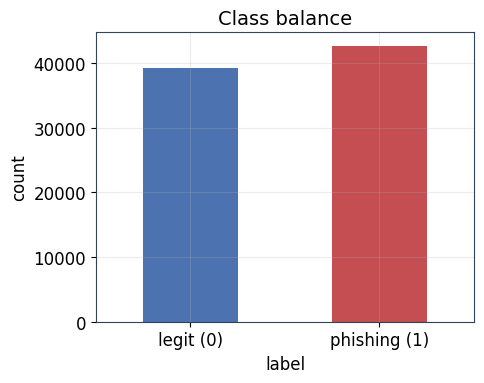

In [8]:
n_total = len(full_df)
class_counts = full_df["label"].value_counts().sort_index()
class_pct = (class_counts / n_total * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Total rows: {n_total:,}")
print(f"Class counts:\n{class_counts}")
print(f"Class %:\n{class_pct}")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

# Force the Jupyter/VSCode INLINE backend explicitly. Merely avoiding an explicit
# matplotlib.use("Agg") is not enough: on a headless machine (no DISPLAY -- common
# in remote/SSH/containerized VSCode sessions, and on Kaggle) matplotlib's own
# auto-detection falls back to Agg anyway, which reproduces the exact same silent
# "plt.show() runs fine but nothing appears" symptom. get_ipython() is provided
# automatically inside any real Jupyter/IPython kernel, so this reliably switches
# to the inline backend there; the try/except is just so this cell does not blow up
# if it is ever executed outside a notebook kernel (e.g. `jupyter nbconvert --to script`).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import matplotlib.pyplot as plt

# Every plot in this notebook also calls plt.savefig(...) into WORKING_DIR / "plots"
# regardless of backend -- if inline display still does not show up in your particular
# editor/UI, open the PNGs there directly; they are the same figures.

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["legit (0)", "phishing (1)"], rotation=0)
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "class_balance.png", dpi=130)
plt.show()

> **Interpretation.** The combined corpus is close to balanced (39,254 legitimate vs.
> 42,638 phishing emails — 47.9% / 52.1%, imbalance ratio 1.09×), so plain accuracy remains a
> meaningful headline metric here, unlike in a heavily skewed detection task. F1 and recall are
> nonetheless kept as the primary metrics throughout (Section 7) in case a real deployment
> population turns out less balanced than this pooled dataset.


### 3.2 Per-source distribution and label purity

A `source` column that is (near-)perfectly correlated with the label is a
**leakage risk in its own right**: a model could learn "which corpus does
this formatting come from" instead of "is this phishing", and that shortcut
would evaporate on new, unseen mail sources. We flag any source whose label
purity exceeds a threshold so it can be excluded as a feature later (Section
4.4) even though it's still useful, here, as a diagnostic.

              n  phishing_rate  purity  high_leakage_risk
source                                                   
ceas      38963          0.556   0.556              False
enron     29423          0.474   0.526              False
unknown    5802          0.295   0.705              False
nigerian   3293          1.000   1.000               True
ling       2859          0.160   0.840              False
nazario    1552          1.000   1.000               True

Sources with >= 98% label purity (source name alone almost determines the label): ['nigerian', 'nazario']


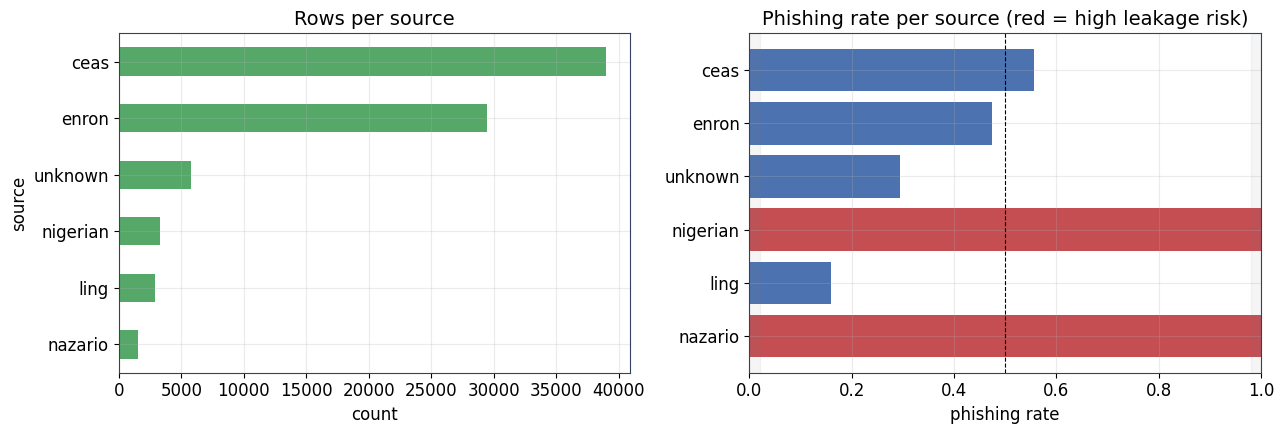

In [9]:
source_summary = (
    full_df.groupby("source")["label"]
    .agg(n="count", phishing_rate="mean")
    .sort_values("n", ascending=False)
)
source_summary["purity"] = source_summary["phishing_rate"].apply(lambda p: max(p, 1 - p))
HIGH_PURITY_THRESHOLD = 0.98
source_summary["high_leakage_risk"] = source_summary["purity"] >= HIGH_PURITY_THRESHOLD

print(source_summary.round(3).to_string())
risky_sources = source_summary[source_summary["high_leakage_risk"]].index.tolist()
print(f"\nSources with >= {HIGH_PURITY_THRESHOLD:.0%} label purity "
      f"(source name alone almost determines the label): {risky_sources}")

source_summary.to_csv(WORKING_DIR / "tables" / "source_label_purity.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
source_summary["n"].sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Rows per source")
axes[0].set_xlabel("count")

sorted_purity = source_summary.sort_values("n")
bar_colors = ["#C44E52" if hi else "#4C72B0" for hi in sorted_purity["high_leakage_risk"]]
axes[1].barh(sorted_purity.index, sorted_purity["phishing_rate"], color=bar_colors)
axes[1].axvline(0.5, color="black", linewidth=0.8, linestyle="--")
axes[1].axvspan(0, 1 - HIGH_PURITY_THRESHOLD, color="gray", alpha=0.08)
axes[1].axvspan(HIGH_PURITY_THRESHOLD, 1, color="gray", alpha=0.08)
axes[1].set_xlim(0, 1)
axes[1].set_title("Phishing rate per source (red = high leakage risk)")
axes[1].set_xlabel("phishing rate")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "source_distribution.png", dpi=130)
plt.show()

> **Interpretation.** Two of the six sources — *Nigerian Fraud* and *Nazario* — are 100%
> phishing, and no source falls below ~53% purity. `source` is therefore a near-perfect predictor
> of the label for at least two corpora: exactly the shortcut a model could learn instead of
> genuine phishing language. This is why `source` is excluded from every model's input features
> (Section 4.4), despite being highly informative here.


### 3.3 Text length distribution by class

Extreme, class-correlated length differences are themselves a shortcut a
model can exploit instead of learning content — worth knowing about even if
we don't act on it directly.

label                          0             1
_word_count count   39254.000000  4.263800e+04
            mean      364.018546  2.017815e+02
            std       865.521166  7.450825e+02
            min         2.000000  2.000000e+00
            25%        95.000000  4.000000e+01
            50%       190.000000  8.800000e+01
            75%       377.000000  2.640000e+02
            max     45450.000000  1.271270e+05
_char_count count   39254.000000  4.263800e+04
            mean     2142.636139  1.386621e+03
            std      5250.526150  2.278490e+04
            min        16.000000  3.000000e+00
            25%       554.000000  2.370000e+02
            50%      1092.000000  4.890000e+02
            75%      2126.000000  1.471000e+03
            max    299251.000000  4.560761e+06


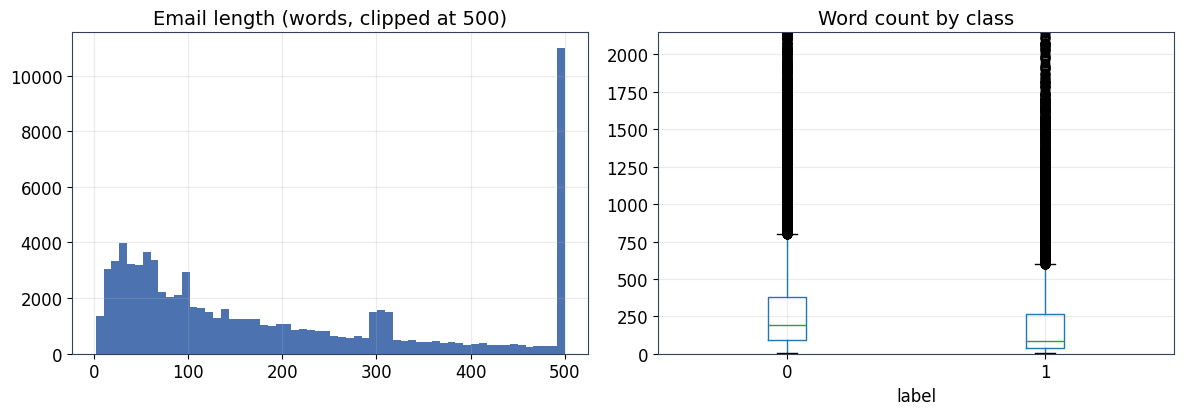

In [10]:
full_df["_word_count"] = full_df["text"].astype(str).str.split().apply(len)
full_df["_char_count"] = full_df["text"].astype(str).str.len()

print(full_df.groupby("label")[["_word_count", "_char_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clipped = full_df["_word_count"].clip(upper=500)
axes[0].hist(clipped, bins=60, color="#4C72B0")
axes[0].set_title("Email length (words, clipped at 500)")

full_df.boxplot(column="_word_count", by="label", ax=axes[1])
axes[1].set_title("Word count by class")
axes[1].set_ylim(0, full_df["_word_count"].quantile(0.99))
plt.suptitle("")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "length_distributions.png", dpi=130)
plt.show()

> **Interpretation.** Legitimate emails are markedly longer than phishing emails on average
> (median 190 vs. 88 words; mean 364 vs. 202 words) — consistent with phishing's tendency toward
> short, action-driving messages rather than the long threads and newsletters common in
> Enron-style legitimate mail. Section 3.6 confirms this gap is statistically significant but only
> a **small** effect (Cohen's *d* = -0.20), so length alone is informative but far from a reliable
> standalone signal.


### 3.4 Vocabulary / n-gram signal check

A quick, model-free look at which unigrams are most associated with each
class (by frequency ratio) — sanity-checks that the signal looks like
genuine phishing language (urgency, credential/verification requests, links)
rather than pure dataset artefacts (e.g. a boilerplate footer only one
source uses).

Top words associated with PHISHING:
lllp, linkto, dailytop10, montauk, wynter, garr, dnt, karadzic, usaa, gotti, sot, computron, maggot, anniv, billclinton

Top words associated with LEGITIMATE mail:
enron, dynegy, opensuse, 40tangomu, spambayes, 2520262, win32, virscan, tuxonice, dbcaps, mmbtu, ffcf14, fefc1771766301, ecostemail, fe5d16747d670c757515


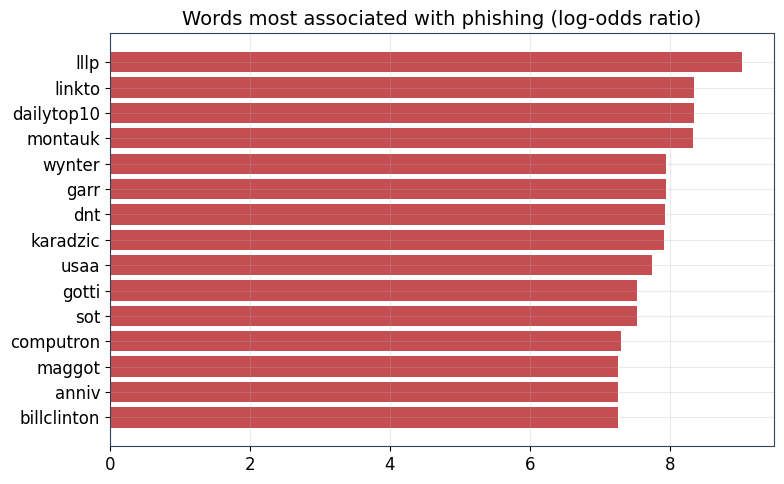

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=20000, ngram_range=(1, 1), stop_words="english", min_df=5)
X_counts = cv.fit_transform(full_df["text"].astype(str))
cv_vocab = np.array(cv.get_feature_names_out())

phish_counts = np.asarray(X_counts[full_df["label"].values == 1].sum(axis=0)).ravel()
legit_counts = np.asarray(X_counts[full_df["label"].values == 0].sum(axis=0)).ravel()

# Laplace-smoothed log-ratio so rare words don't dominate
eps = 1.0
log_ratio = np.log((phish_counts + eps) / (phish_counts.sum() + eps)) - \
            np.log((legit_counts + eps) / (legit_counts.sum() + eps))

min_count_mask = (phish_counts + legit_counts) >= 30
top_phish_idx = np.argsort(np.where(min_count_mask, log_ratio, -np.inf))[::-1][:15]
top_legit_idx = np.argsort(np.where(min_count_mask, -log_ratio, -np.inf))[::-1][:15]

print("Top words associated with PHISHING:")
print(", ".join(cv_vocab[top_phish_idx]))
print("\nTop words associated with LEGITIMATE mail:")
print(", ".join(cv_vocab[top_legit_idx]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cv_vocab[top_phish_idx][::-1], log_ratio[top_phish_idx][::-1], color="#C44E52")
ax.set_title("Words most associated with phishing (log-odds ratio)")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "top_phishing_words.png", dpi=130)
plt.show()

> **Reading this table with care.** Most of the words listed are corpus identifiers or mailing-list boilerplate rather than phishing language -- e.g. `enron`, `dynegy`, `opensuse`, `spambayes` on the legitimate side and `lllp`, `dailytop10` on the phishing side -- because each source corpus has its own vocabulary. This is the shortcut risk described in Section 3.2. It is also why the SHAP ranking in Section 16.1 puts `enron` first, and Section 20.2 measures how much the classifier depends on such tokens.

### 3.5 Missing values, empty text & duplicate-label conflicts

Before trusting any downstream statistic, we check for the boring-but-fatal data
issues: nulls, blank/whitespace-only bodies, and rows that are *exact* text
duplicates yet disagree on `label` (a labelling error, not a modelling problem —
no amount of leak-safe splitting fixes a mislabeled template).

In [12]:
null_counts = full_df[["text", "label", "source"]].isna().sum()
print("Null counts:\n", null_counts.to_string())

_stripped = full_df["text"].astype(str).str.strip()
n_empty = int((_stripped == "").sum())
n_very_short = int((_stripped.str.len() < 5).sum())
print(f"\nEmpty/whitespace-only rows: {n_empty:,}")
print(f"Rows with < 5 characters of text: {n_very_short:,}")

# Exact-text duplicates that disagree on label -- a labelling conflict, not leakage.
_conflict_check = (
    full_df.assign(_raw_norm=full_df["text"].astype(str).str.strip().str.lower())
    .groupby("_raw_norm")["label"]
    .agg(["nunique", "count"])
)
label_conflicts = _conflict_check[(_conflict_check["nunique"] > 1) & (_conflict_check["count"] > 1)]
print(f"\nIdentical-text groups with conflicting labels: {len(label_conflicts):,} "
      f"({label_conflicts['count'].sum() if len(label_conflicts) else 0:,} rows affected)")
if len(label_conflicts):
    print("These rows should be resolved (e.g. dropped or relabeled) before training "
          "since the same input maps to two different targets.")


Null counts:
 text      0
label     0
source    0

Empty/whitespace-only rows: 0
Rows with < 5 characters of text: 1

Identical-text groups with conflicting labels: 0 (0 rows affected)


### 3.6 Is the length difference between classes statistically significant?

Section 3.3 showed phishing and legitimate emails have different length
distributions, but eyeballing a histogram isn't a significance test. We use a
Mann-Whitney U test (distribution-free, robust to the heavy right-skew typical
of text-length data) plus Cohen's *d* so we know not just *whether* the
difference is real but whether it's large enough to matter as a modelling
shortcut.

In [13]:
from scipy import stats

phish_wc = full_df.loc[full_df["label"] == 1, "_word_count"]
legit_wc = full_df.loc[full_df["label"] == 0, "_word_count"]

u_stat, p_value = stats.mannwhitneyu(phish_wc, legit_wc, alternative="two-sided")

pooled_std = np.sqrt(((phish_wc.std() ** 2) + (legit_wc.std() ** 2)) / 2)
cohens_d = (phish_wc.mean() - legit_wc.mean()) / pooled_std

def _effect_label(d):
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"

print(f"Mann-Whitney U={u_stat:,.0f}, p={p_value:.2e}")
print(f"Mean word count -- phishing: {phish_wc.mean():.1f}, legit: {legit_wc.mean():.1f}")
print(f"Cohen's d = {cohens_d:.3f} ({_effect_label(cohens_d)} effect)")
if p_value < 0.05:
    print("\n-> Statistically significant, but remember: a large N makes even tiny, "
          "practically meaningless differences 'significant'. The effect size above "
          "is what actually tells us whether length is a usable (or exploitable) signal.")


Mann-Whitney U=558,237,928, p=0.00e+00
Mean word count -- phishing: 201.8, legit: 364.0
Cohen's d = -0.201 (small effect)

-> Statistically significant, but remember: a large N makes even tiny, practically meaningless differences 'significant'. The effect size above is what actually tells us whether length is a usable (or exploitable) signal.


### 3.7 Stylistic signals: punctuation, casing & symbol usage

Phishing copy tends to lean on urgency and visual emphasis (ALL CAPS, exclamation
marks, dollar signs, raw URLs). These are cheap, model-free signals worth
checking before we build hand-crafted features in Section 6 -- if they barely
differ by class they're not worth engineering; if they differ a lot, that's
either genuine signal or another shortcut risk to keep an eye on.

              legit (0)  phishing (1)
upper_ratio      0.0287        0.0543
exclam_count     1.0601        1.5511
digit_ratio      0.0344        0.0240
url_count        2.4541        3.7991
dollar_count     1.0988        0.8433


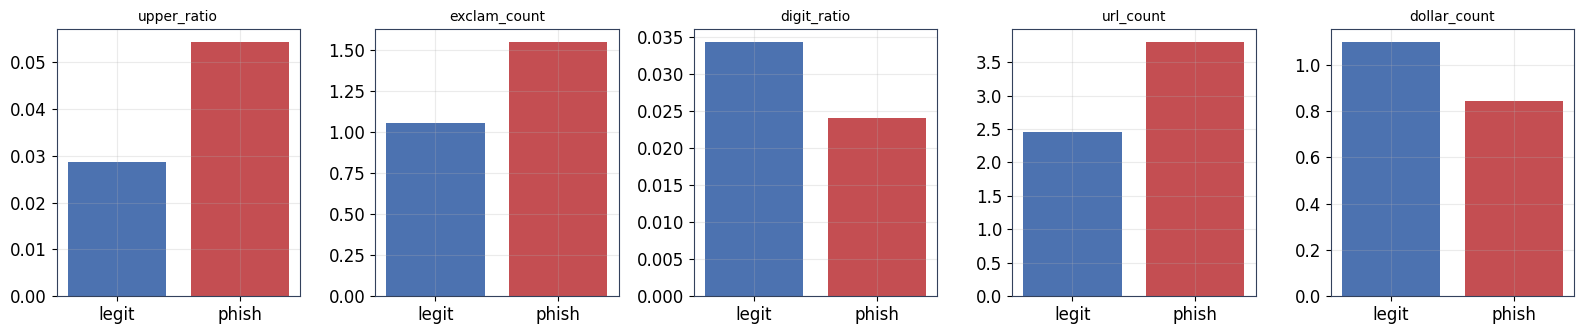

In [14]:
_text = full_df["text"].astype(str)

style_df = pd.DataFrame({
    "label": full_df["label"].values,
    "upper_ratio": _text.apply(lambda t: sum(1 for ch in t if ch.isupper()) / max(len(t), 1)),
    "exclam_count": _text.str.count("!"),
    "digit_ratio": _text.apply(lambda t: sum(1 for ch in t if ch.isdigit()) / max(len(t), 1)),
    "url_count": _text.str.count(r"https?://|www\."),
    "dollar_count": _text.str.count(r"\$"),
})

style_summary = style_df.groupby("label").mean().T
style_summary.columns = ["legit (0)", "phishing (1)"]
print(style_summary.round(4).to_string())

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, col in zip(axes, ["upper_ratio", "exclam_count", "digit_ratio", "url_count", "dollar_count"]):
    means = style_df.groupby("label")[col].mean()
    ax.bar(["legit", "phish"], means.values, color=["#4C72B0", "#C44E52"])
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "stylistic_signals.png", dpi=130)
plt.show()


### 3.8 Correlation between stylistic signals and the label

A quick correlation matrix ties Sections 3.3/3.6/3.7 together in one view:
which of these cheap, model-free signals move together, and which actually
correlate with the label at all. High inter-feature correlation here is also a
heads-up for redundancy if these are reused as model inputs in Section 6.

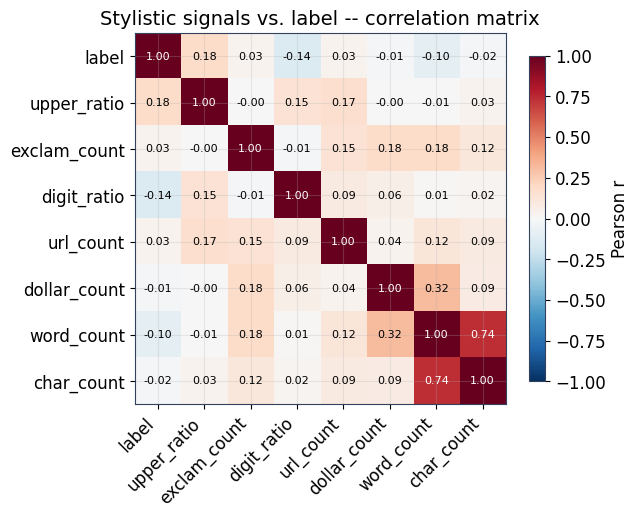

Correlation with label, sorted by |r|:
upper_ratio     0.180
digit_ratio    -0.139
word_count     -0.100
exclam_count    0.034
url_count       0.033
char_count     -0.022
dollar_count   -0.014


In [15]:
corr_df = style_df.assign(word_count=full_df["_word_count"], char_count=full_df["_char_count"])
corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix.values[i, j]) > 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Stylistic signals vs. label -- correlation matrix")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "stylistic_corr_heatmap.png", dpi=130)
plt.show()

print("Correlation with label, sorted by |r|:")
print(corr_matrix["label"].drop("label").sort_values(key=abs, ascending=False).round(3).to_string())


### 3.9 Low-dimensional view of the text embedding space

A 2-D projection of the bag-of-words space (via Truncated SVD -- the sparse-
matrix analogue of PCA, reused from the `CountVectorizer` fit in Section 3.4)
gives a fast, model-free sense of how separable the two classes already are
from raw word counts alone, before any classifier is trained. Heavy overlap
here would suggest the eventual classifiers will lean heavily on subtler
patterns than "which words appear"; a visible split is a good sign that even
simple baselines should do reasonably well.

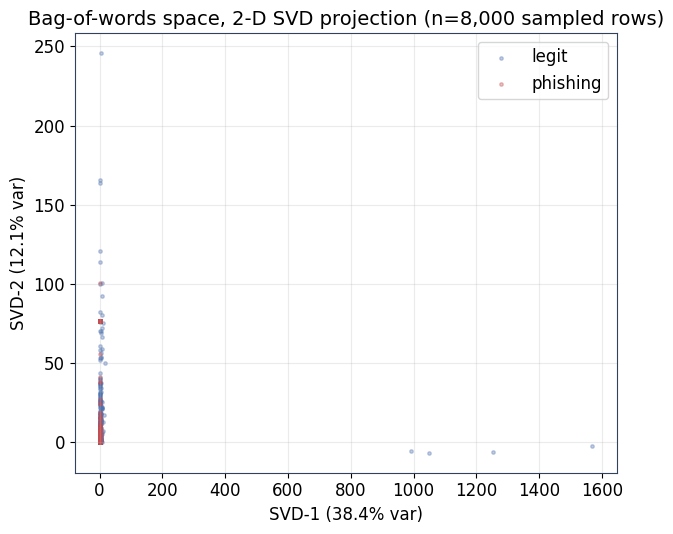

Combined variance explained by first 2 components: 50.5% (low is expected/normal for BoW; this plot is a qualitative sanity check, not a full picture of separability).


In [16]:
from sklearn.decomposition import TruncatedSVD

_svd_sample_n = min(8000, X_counts.shape[0])
_rng = np.random.RandomState(SEED)
_sample_idx = _rng.choice(X_counts.shape[0], size=_svd_sample_n, replace=False)

svd = TruncatedSVD(n_components=2, random_state=SEED)
X_2d = svd.fit_transform(X_counts[_sample_idx])
sample_labels = full_df["label"].values[_sample_idx]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for lbl, name, color in [(0, "legit", "#4C72B0"), (1, "phishing", "#C44E52")]:
    mask = sample_labels == lbl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=6, alpha=0.35, label=name, color=color)
ax.set_xlabel(f"SVD-1 ({svd.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"SVD-2 ({svd.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"Bag-of-words space, 2-D SVD projection (n={_svd_sample_n:,} sampled rows)")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "svd_projection.png", dpi=130)
plt.show()
print(f"Combined variance explained by first 2 components: "
      f"{svd.explained_variance_ratio_.sum():.1%} (low is expected/normal for BoW; "
      "this plot is a qualitative sanity check, not a full picture of separability).")


### 3.10 Linguistic pattern analysis (function words, imperatives, readability)

Beyond raw length and symbol counts, phishing relies on a distinctive *register*: second-person address, imperative verbs, and simplified sentence structure designed to be skimmed and acted on quickly under time pressure. We quantify this with three cheap, model-free proxies:
1. **Second-person pronoun ratio** (`you`/`your`) -- direct address is a    hallmark of persuasive/urgent copy.
2. **Imperative-verb hits** -- sentence-initial command verbs (`click`,    `verify`, `confirm`, `update`, `download`, ...).
3. **Flesch reading ease** (approximate, syllable-heuristic version, so no    extra NLP dependency is required) -- phishing templates are typically    written for very easy, fast reading.

(Computed on a random sample of 6,000 rows for speed.)

      second_person_ratio        imperative_hits        flesch_reading_ease        
                     mean median            mean median                mean  median
label                                                                              
0                   0.011  0.006           2.703    1.0              60.897  64.617
1                   0.030  0.024           1.968    1.0              56.149  63.509


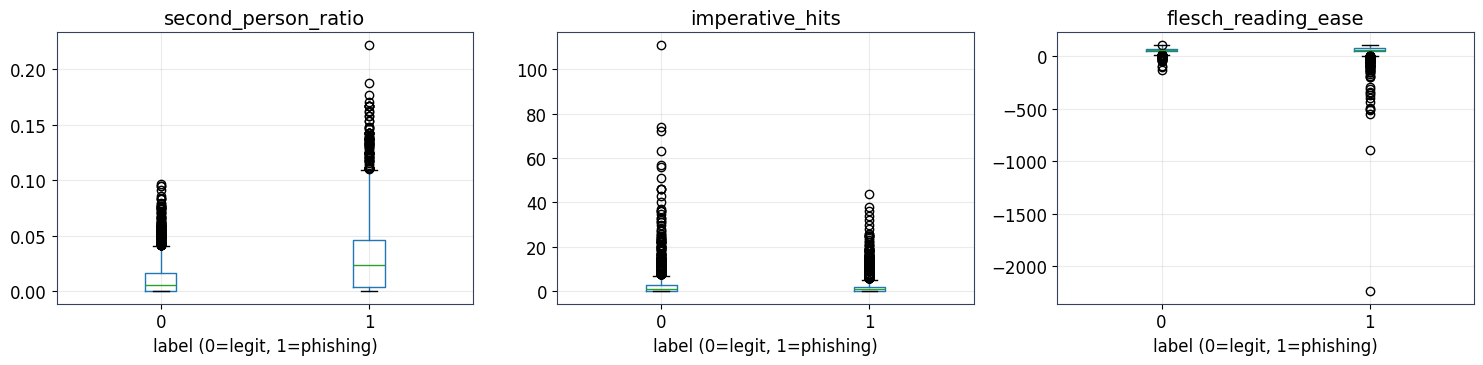


Higher second-person ratio / imperative-verb counts and an easier (higher) Flesch score for phishing would support the 'act now, in simple language, addressed directly at you' hypothesis about phishing register.


In [17]:
import re as _re

_SECOND_PERSON = _re.compile(
    r"\b(you|your|you're|youre)\b",
    _re.IGNORECASE
)

_IMPERATIVE_VERBS = [
    "click", "verify", "confirm", "update", "download", "login",
    "log in", "reset", "act", "call", "respond", "open"
]

def _count_second_person(t):
    return len(_SECOND_PERSON.findall(t))

def _count_imperatives(t):
    tl = t.lower()
    return sum(tl.count(v) for v in _IMPERATIVE_VERBS)

def _count_syllables(word):
    word = word.lower()
    vowels = "aeiouy"
    count, prev_is_vowel = 0, False

    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_is_vowel:
            count += 1
        prev_is_vowel = is_vowel

    if word.endswith("e") and count > 1:
        count -= 1

    return max(count, 1)

def _flesch_reading_ease(t):
    words = _re.findall(r"[A-Za-z']+", t)
    sentences = max(len(_re.findall(r"[.!?]+", t)), 1)

    if not words:
        return np.nan

    n_words = len(words)
    n_syll = sum(_count_syllables(w) for w in words)

    return (
        206.835
        - 1.015 * (n_words / sentences)
        - 84.6 * (n_syll / n_words)
    )

_ling_sample_n = min(6000, len(full_df))
_ling_idx = full_df.sample(_ling_sample_n, random_state=SEED).index
_ling_text = full_df.loc[_ling_idx, "text"].astype(str)

linguistic_df = pd.DataFrame({
    "label": full_df.loc[_ling_idx, "label"].values,

    "second_person_ratio": (
        _ling_text.apply(_count_second_person)
        / _ling_text.str.split().apply(len).replace(0, 1)
    ),

    "imperative_hits": _ling_text.apply(_count_imperatives),

    "flesch_reading_ease": _ling_text.apply(_flesch_reading_ease),
})

ling_summary = linguistic_df.groupby("label").agg(["mean", "median"]).round(3)

print(f"(Computed on a random sample of {_ling_sample_n:,} rows for speed.)\n")
print(ling_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(
    axes,
    ["second_person_ratio", "imperative_hits", "flesch_reading_ease"]
):
    linguistic_df.boxplot(
        column=col,
        by="label",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("label (0=legit, 1=phishing)")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    WORKING_DIR / "plots" / "linguistic_patterns.png",
    dpi=130
)

plt.show()

print(
    "\nHigher second-person ratio / imperative-verb counts and an easier "
    "(higher) Flesch score for phishing would support the 'act now, in simple "
    "language, addressed directly at you' hypothesis about phishing register."
)

### 3.11 EDA insights summary

A single, decision-oriented recap of Sections 3.1-3.10, written *before* any
model is trained, so later results can be checked against these expectations
rather than the narrative being written backwards from them.

In [18]:
_eda_insights = []

_eda_insights.append(f"Class balance is {class_pct.to_dict()} (imbalance ratio "
                     f"{imbalance_ratio:.2f}x) -- close enough to balanced that plain "
                     "accuracy is still meaningful, but F1/recall remain the primary metrics.")

if len(risky_sources):
    _eda_insights.append(f"Sources {risky_sources} are >= {HIGH_PURITY_THRESHOLD:.0%} pure in one "
                         "class -- 'source' is excluded as a model input (Section 4.4) to avoid a "
                         "corpus-identity shortcut.")
else:
    _eda_insights.append("No source shows near-perfect label purity -- lower source-leakage risk, "
                         "but 'source' is still excluded as an input on principle (Section 4.4).")

# (Computed here, ahead of the insight text below, since this notebook's EDA-insight-summary needs the duplicate-template count and the leakage/near-duplicate audit section 4 will independently recompute a URL-masked version of this for its own narrative.)
_dup_norm_text = (
    full_df["text"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
_dup_counts = _dup_norm_text.value_counts()
n_dupe_rows = int(_dup_counts[_dup_counts > 1].sum())
n_dupe_templates = int((_dup_counts > 1).sum())

_eda_insights.append(f"{n_dupe_rows:,} rows ({n_dupe_rows/len(full_df):.1%}) share a normalized "
                     "duplicate template -- this is *why* Section 4.3 uses a grouped split instead "
                     "of a plain random one.")

_eda_insights.append(f"Word-count difference between classes has Cohen's d={cohens_d:.2f} "
                     f"({_effect_label(cohens_d)}) -- length alone is a weak-to-moderate signal, "
                     "not a reliable shortcut on its own.")

_top_style_corr = corr_matrix['label'].drop('label').abs().sort_values(ascending=False).index[0]
_eda_insights.append(f"'{_top_style_corr}' has the strongest linear correlation with the label among "
                     "the cheap stylistic signals -- a candidate for the engineered-feature set "
                     "in Section 6.")

print("EDA -> modelling implications:")
for i, s in enumerate(_eda_insights, 1):
    print(f"  {i}. {s}")

with open(WORKING_DIR / "tables" / "eda_insights.json", "w") as f:
    json.dump(_eda_insights, f, indent=2)


EDA -> modelling implications:
  1. Class balance is {0: 47.93, 1: 52.07} (imbalance ratio 1.09x) -- close enough to balanced that plain accuracy is still meaningful, but F1/recall remain the primary metrics.
  2. Sources ['nigerian', 'nazario'] are >= 98% pure in one class -- 'source' is excluded as a model input (Section 4.4) to avoid a corpus-identity shortcut.
  3. 8 rows (0.0%) share a normalized duplicate template -- this is *why* Section 4.3 uses a grouped split instead of a plain random one.
  4. Word-count difference between classes has Cohen's d=-0.20 (small) -- length alone is a weak-to-moderate signal, not a reliable shortcut on its own.
  5. 'upper_ratio' has the strongest linear correlation with the label among the cheap stylistic signals -- a candidate for the engineered-feature set in Section 6.


In [19]:
# Duplicate-template rows/templates were already computed above (used by the EDA insight summary); this cell just reports them.
print(
    f"Duplicate-template rows : {n_dupe_rows:,} "
    f"({n_dupe_rows / len(full_df):.1%})"
)

print(
    f"Duplicate templates     : {n_dupe_templates:,}"
)


Duplicate-template rows : 8 (0.0%)
Duplicate templates     : 4


<a id="sec4"></a>

## 4. Data Leakage Prevention & Leak-Safe Split

This is the single most important correction made when merging the two
source notebooks. Originally, the classical baselines (Notebook 02) trained
on a plain random/stratified split, and only the Transformer notebook
(Notebook 03) discovered — *after the fact* — that the corpus contains many
duplicate/near-duplicate templates (the same phishing email reused across
sources), re-split the data to fix it, and only then re-evaluated the
Transformers. That means the two families of models were never scored on a
comparable footing.

Here, the audit and the fix run **once, before any model is trained**, so
every one of the five final models — baselines, Transformers, and the custom
model — is trained and evaluated on the same leak-free split.

### 4.1 Exact-duplicate audit

In [20]:
full_df["_norm_text"] = (
    full_df["text"].astype(str).str.lower()
    .str.replace(r"http\S+|www\.\S+", " <url> ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

dup_mask = full_df.duplicated(subset="_norm_text", keep=False)
n_dupe_rows = int(dup_mask.sum())
print(f"{n_dupe_rows:,} rows ({n_dupe_rows / len(full_df):.1%}) share a normalized "
      "duplicate template with at least one other row.")

if _mode == "presplit":
    template_split_counts = full_df[dup_mask].groupby("_norm_text")["_orig_split"].nunique()
    leaking_templates = template_split_counts[template_split_counts > 1]
    n_leaked_rows = full_df[dup_mask & full_df["_norm_text"].isin(leaking_templates.index)].shape[0]
    print(f"{len(leaking_templates):,} templates appear in MORE THAN ONE of the "
          f"original train/val/test splits -- direct leakage affecting "
          f"{n_leaked_rows:,} rows. This is exactly what the grouped re-split "
          "below eliminates.")
else:
    print("No pre-existing split to check for cross-split duplication (we are "
          "splitting fresh below) -- duplicates will simply be grouped so they "
          "cannot land in more than one split in the first place.")

5,318 rows (6.5%) share a normalized duplicate template with at least one other row.
399 templates appear in MORE THAN ONE of the original train/val/test splits -- direct leakage affecting 4,489 rows. This is exactly what the grouped re-split below eliminates.


### 4.2 Near-duplicate audit (diagnostic)

Exact-match dedup won't catch templates that differ only by a substituted
name, date, or link. This is a cheaper secondary signal: sample rows, find
their nearest neighbour elsewhere in the pool by TF-IDF cosine similarity,
and see how often that similarity is suspiciously close to 1.0.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer as _TV
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

NEAR_DUP_THRESHOLD = 0.95

# --- Diagnostic pass (unchanged from before): quick sampled estimate of the
# near-duplicate rate, cheap enough to run first and sanity-check the scale
# of the problem before committing to full clustering below.
SAMPLE_SIZE = min(3000, len(full_df) // 2)
_probe_idx = full_df.sample(SAMPLE_SIZE, random_state=SEED).index
_rest_idx = full_df.index.difference(_probe_idx)

_vec = _TV(max_features=20000, ngram_range=(1, 2))
_rest_vecs = _vec.fit_transform(full_df.loc[_rest_idx, "_norm_text"])
_probe_vecs = _vec.transform(full_df.loc[_probe_idx, "_norm_text"])

_nn = NearestNeighbors(n_neighbors=1, metric="cosine").fit(_rest_vecs)
_dist, _ = _nn.kneighbors(_probe_vecs)
_sim = 1 - _dist.ravel()

near_dup_rate = float((_sim >= NEAR_DUP_THRESHOLD).mean())
print(f"Of {SAMPLE_SIZE:,} sampled rows, {near_dup_rate:.1%} have a near-identical "
      f"(cosine sim >= {NEAR_DUP_THRESHOLD}) match elsewhere in the pool.")
print(f"Median nearest-neighbour similarity: {np.median(_sim):.3f}")

# Rationale for this logic: see Appendix A (change log).
MAX_ROWS_FOR_FULL_NEARDUP_CLUSTERING = 120_000

if len(full_df) <= MAX_ROWS_FOR_FULL_NEARDUP_CLUSTERING:
    _full_vec = _TV(max_features=30000, ngram_range=(1, 2), min_df=2)
    _full_vecs = _full_vec.fit_transform(full_df["_norm_text"])

    # radius_neighbors_graph with cosine distance: an edge for every pair whose
    # cosine similarity is >= NEAR_DUP_THRESHOLD (distance <= 1 - threshold).
    _radius = 1.0 - NEAR_DUP_THRESHOLD
    _nn_full = NearestNeighbors(radius=_radius, metric="cosine", n_jobs=-1).fit(_full_vecs)
    near_dup_adj = _nn_full.radius_neighbors_graph(_full_vecs, mode="connectivity")

    # Exact-duplicate text is already a perfect near-duplicate; folding the
    # `_norm_text` equality into the same adjacency guarantees exact-dup rows
    # end up in the same cluster as their near-dup neighbours too.
    _exact_codes = full_df["_norm_text"].astype("category").cat.codes.values
    _exact_adj = sp.csr_matrix(
        (np.ones(len(full_df)), (np.arange(len(full_df)), _exact_codes))
    )
    _exact_adj = _exact_adj @ _exact_adj.T  # rows sharing a code -> connected

    combined_adj = ((near_dup_adj + _exact_adj) > 0).astype(int)
    n_clusters, cluster_ids = connected_components(combined_adj, directed=False)
    full_df["_dup_cluster"] = cluster_ids

    cluster_sizes = pd.Series(cluster_ids).value_counts()
    n_multi_row_clusters = int((cluster_sizes > 1).sum())
    n_rows_in_multi_clusters = int(cluster_sizes[cluster_sizes > 1].sum())
    print(f"\nNear-dup + exact-dup clustering: {n_clusters:,} clusters total, "
          f"{n_multi_row_clusters:,} of them contain >1 row "
          f"({n_rows_in_multi_clusters:,} rows, "
          f"{n_rows_in_multi_clusters / len(full_df):.1%} of the dataset). "
          "These clusters -- not raw row identity -- are the grouping key used "
          "by the leak-safe split below (Section 4.3), so no near-duplicate "
          "template can land in more than one of train/val/test.")
    SPLIT_GROUP_COL = "_dup_cluster"
else:
    print(f"\n[INFO] {len(full_df):,} rows exceeds the "
          f"{MAX_ROWS_FOR_FULL_NEARDUP_CLUSTERING:,}-row cap for full pairwise "
          "near-duplicate clustering (O(n) radius queries over a large sparse "
          "matrix become slow/memory-heavy at this scale). Falling back to "
          "exact-duplicate grouping only (_norm_text) for the split in Section "
          "4.3 -- documented here as a known, explicit limitation rather than a "
          "silent gap; near-duplicate leakage above the sampled rate reported "
          "above may still exist in this fallback mode.")
    full_df["_dup_cluster"] = full_df["_norm_text"].astype("category").cat.codes.values
    SPLIT_GROUP_COL = "_norm_text"

if near_dup_rate > 0.05 and SPLIT_GROUP_COL == "_norm_text":
    print("[WARN] Meaningful near-duplicate rate detected but full clustering was "
          "skipped (see above) -- near-duplicate leakage risk remains.")


Of 3,000 sampled rows, 26.7% have a near-identical (cosine sim >= 0.95) match elsewhere in the pool.
Median nearest-neighbour similarity: 0.805

Near-dup + exact-dup clustering: 65,976 clusters total, 4,551 of them contain >1 row (20,467 rows, 25.0% of the dataset). These clusters -- not raw row identity -- are the grouping key used by the leak-safe split below (Section 4.3), so no near-duplicate template can land in more than one of train/val/test.


### 4.3 Grouped, leakage-free split

Every exact-duplicate template is forced to stay inside a single split via
`GroupShuffleSplit`, keyed on the normalized text. This is the split every
model below trains and is evaluated on.

In [22]:
from sklearn.model_selection import GroupShuffleSplit

groups = full_df[SPLIT_GROUP_COL]  # bug fix: was hardcoded to "_norm_text" (exact-dup only);
                                    # now uses the near-dup+exact-dup cluster id from Section 4.2.

# Rationale for this logic: see Appendix A (change log).
def _split_has_both_classes(df):
    return df["label"].nunique() == 2

def _make_grouped_split(seed):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    trainval_idx, test_idx = next(gss_test.split(full_df, groups=groups))
    trainval_df = full_df.iloc[trainval_idx].reset_index(drop=True)
    test_df = full_df.iloc[test_idx].reset_index(drop=True)

    gss_val = GroupShuffleSplit(n_splits=1, test_size=VAL_FRAC_OF_REMAINDER, random_state=seed)
    train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df[SPLIT_GROUP_COL]))
    train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
    val_df = trainval_df.iloc[val_idx].reset_index(drop=True)
    return train_df, val_df, test_df

N_SPLIT_RETRIES = 25
train_df = val_df = test_df = None
for _attempt in range(N_SPLIT_RETRIES):
    _seed = SEED + _attempt
    _train_df, _val_df, _test_df = _make_grouped_split(_seed)
    if all(_split_has_both_classes(d) for d in (_train_df, _val_df, _test_df)):
        train_df, val_df, test_df = _train_df, _val_df, _test_df
        if _attempt > 0:
            print(f"[INFO] Grouped split needed {_attempt + 1} seed attempt(s) before every "
                  "split contained both classes (expected with very few template clusters, "
                  "e.g. this notebook's small synthetic fallback data).")
        break

if train_df is None:
    print("[WARN] Could not find a group-safe split with both classes in every split after "
          f"{N_SPLIT_RETRIES} attempts (too few distinct template clusters of the minority "
          "class). Falling back to a plain stratified split -- leak-safety across near-"
          "duplicate templates is NOT guaranteed in this fallback; it only triggers on "
          "pathologically small/low-diversity data such as the synthetic placeholder set.")
    from sklearn.model_selection import train_test_split as _tts
    trainval_df, test_df = _tts(full_df, test_size=TEST_FRAC, stratify=full_df["label"],
                                 random_state=SEED)
    train_df, val_df = _tts(trainval_df, test_size=VAL_FRAC_OF_REMAINDER,
                             stratify=trainval_df["label"], random_state=SEED)
    train_df, val_df, test_df = (d.reset_index(drop=True) for d in (train_df, val_df, test_df))

groups_by_split = {name: set(d[SPLIT_GROUP_COL]) for name, d in
                    [("train", train_df), ("val", val_df), ("test", test_df)]}
assert not (groups_by_split["train"] & groups_by_split["val"]), "template leaked train/val"
assert not (groups_by_split["train"] & groups_by_split["test"]), "template leaked train/test"
assert not (groups_by_split["val"] & groups_by_split["test"]), "template leaked val/test"
print("Verified: no template appears in more than one split.\n")

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):7,} rows | phishing rate: {d['label'].mean():.3f}")

train_df.to_csv(WORKING_DIR / "audit" / "train_deduped.csv", index=False)
val_df.to_csv(WORKING_DIR / "audit" / "val_deduped.csv", index=False)
test_df.to_csv(WORKING_DIR / "audit" / "test_deduped.csv", index=False)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values


Verified: no template appears in more than one split.

train:  58,280 rows | phishing rate: 0.530
val  :  11,503 rows | phishing rate: 0.481
test :  12,109 rows | phishing rate: 0.514


### 4.4 Feature inclusion/exclusion audit

Before any feature is used, we document *why*. `source` is diagnostic gold
for EDA but is excluded as a model **input** because Section 3.2 showed some
sources are near-perfectly pure in one class — a model given `source`
directly could "cheat" by memorising corpus identity instead of learning
phishing language, which would not generalise to new mail sources.

In [23]:
feature_audit_rows = [
    {"column": "text / text_clean", "used_as_input": True,
     "reason": "Primary modelling signal."},
    {"column": "source", "used_as_input": False,
     "reason": f"Near-perfect label purity for some sources "
               f"({risky_sources}) -- using it directly would let a model "
               "shortcut on corpus identity rather than content. Kept only "
               "for EDA / grouped-split diagnostics."},
    {"column": "_norm_text", "used_as_input": False,
     "reason": "Helper column created purely for the leakage/grouping audit."},
    {"column": "_word_count / _char_count", "used_as_input": "engineered feature",
     "reason": "Kept, but as an explicit engineered numeric feature (Section 6), "
               "not the raw column, and always fit/derived from TRAIN statistics only."},
]
feature_audit_df = pd.DataFrame(feature_audit_rows)
feature_audit_df.to_csv(WORKING_DIR / "tables" / "feature_inclusion_exclusion.csv", index=False)
feature_audit_df

,column,used_as_input,reason
0,text / text_clean,True,Primary modelling signal.
1,source,False,Near-perfect label purity for some sources (['...
2,_norm_text,False,Helper column created purely for the leakage/g...
3,_word_count / _char_count,engineered feature,"Kept, but as an explicit engineered numeric fe..."


<a id="sec5"></a>

## 5. Advanced Text Preprocessing

`clean_text()` is applied identically to every split. It:
1. Lowercases and strips HTML tags.
2. **Replaces URLs, email addresses, and long digit runs with placeholder
   tokens** (`<url>`, `<email>`, `<num>`) instead of deleting them — this
   preserves the *signal* that a link/number was present (often a strong
   phishing cue) while destroying the *exact* template text that made
   near-duplicate memorisation possible in Section 4.2.
2. Collapses whitespace and strips leftover punctuation noise.

Any statistic used for cleaning (e.g. a vocabulary) is derived **only** from
training data where relevant; here `clean_text` is a stateless function, so
this is naturally satisfied, but we call it out because Section 6's scaler
and Section 8-10's vectorizers/tokenizers are explicitly fit on `train_df`
only.

In [24]:
import re

_html_re = re.compile(r"<[^>]+>")
_url_re = re.compile(r"(https?://\S+|www\.\S+)")
_email_re = re.compile(r"\S+@\S+\.\S+")
_num_re = re.compile(r"\b\d{2,}\b")
_ws_re = re.compile(r"\s+")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" <url> ", text)
    text = _email_re.sub(" <email> ", text)
    text = _num_re.sub(" <num> ", text)
    text = re.sub(r"[^a-z0-9<>!?$%. ]", " ", text)
    text = _ws_re.sub(" ", text).strip()
    return text

for _d in (train_df, val_df, test_df):
    _d["text_clean"] = _d["text"].apply(clean_text)

print("Before:", train_df["text"].iloc[0][:150])
print("After: ", train_df["text_clean"].iloc[0][:150])

Before: important message - make it longer > longer orgasms - the longest most intense orgasms of your life > rock hard eractions - erections like steel > > i
After:  important message make it longer > longer orgasms the longest most intense orgasms of your life > rock hard eractions erections like steel > > increas


<a id="sec6"></a>

## 6. Feature Engineering

Hand-crafted features that capture phishing *style* independently of exact
wording — useful both as a diagnostic and as direct input to the custom
model in Section 10 (fused alongside its learned text representation).
All scaling statistics are fit on `train_df` only and re-used (never
re-fit) on val/test.

### 6.1 Hand-crafted feature extraction

Eleven cheap, model-free features capturing length, symbol usage, and a small urgency lexicon -- documented in full, with cybersecurity rationale, in Section 6.2 below.

In [25]:
URGENCY_WORDS = ["urgent", "verify", "suspend", "immediately", "password",
                  "click", "confirm", "account", "limited", "expire", "act now",
                  "security alert", "winner", "congratulations"]

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    text = df["text"].astype(str)
    feats = pd.DataFrame(index=df.index)
    feats["word_count"] = text.str.split().apply(len)
    feats["char_count"] = text.str.len()
    feats["avg_word_len"] = feats["char_count"] / feats["word_count"].replace(0, 1)
    feats["url_count"] = text.str.count(r"https?://|www\.")
    feats["email_count"] = text.str.count(r"\S+@\S+\.\S+")
    feats["digit_count"] = text.str.count(r"\d")
    feats["exclaim_count"] = text.str.count("!")
    feats["question_count"] = text.str.count(r"\?")
    feats["upper_ratio"] = text.apply(
        lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
    lowered = text.str.lower()
    feats["urgency_word_count"] = lowered.apply(
        lambda t: sum(t.count(w) for w in URGENCY_WORDS))
    feats["has_link"] = (feats["url_count"] > 0).astype(int)
    return feats

train_feats_raw = engineer_features(train_df)
val_feats_raw = engineer_features(val_df)
test_feats_raw = engineer_features(test_df)

FEATURE_COLS = train_feats_raw.columns.tolist()
print("Engineered features:", FEATURE_COLS)

from sklearn.preprocessing import StandardScaler
feat_scaler = StandardScaler().fit(train_feats_raw)   # fit on TRAIN only

train_feats = pd.DataFrame(feat_scaler.transform(train_feats_raw), columns=FEATURE_COLS)
val_feats = pd.DataFrame(feat_scaler.transform(val_feats_raw), columns=FEATURE_COLS)
test_feats = pd.DataFrame(feat_scaler.transform(test_feats_raw), columns=FEATURE_COLS)

# Quick sanity check: are engineered features actually informative?
corr_with_label = train_feats_raw.assign(label=y_train).corr()["label"].drop("label")
print("\nCorrelation of engineered features with label (train):")
print(corr_with_label.sort_values(key=abs, ascending=False).round(3).to_string())

Engineered features: ['word_count', 'char_count', 'avg_word_len', 'url_count', 'email_count', 'digit_count', 'exclaim_count', 'question_count', 'upper_ratio', 'urgency_word_count', 'has_link']

Correlation of engineered features with label (train):
upper_ratio           0.194
avg_word_len          0.132
word_count           -0.113
urgency_word_count    0.077
char_count           -0.063
url_count             0.051
digit_count          -0.039
exclaim_count         0.025
has_link              0.024
question_count        0.007
email_count           0.002


### 6.2 Feature documentation map & importance analysis

Every engineered feature is documented on four axes -- **what it measures**,
**how it's computed**, **why it matters for phishing detection specifically**,
and **where it's actually used** in this pipeline (only the custom hybrid model
in Section 10 fuses these directly; the TF-IDF/Transformer models use raw text).
We then fit a quick, disposable Logistic Regression on the scaled engineered
features alone (train split only) purely to rank them by importance -- this
model is **not** one of the finalists, it's a diagnostic.

In [26]:
FEATURE_DOCUMENTATION = pd.DataFrame([
    {"feature": "word_count", "meaning": "Number of whitespace-separated tokens.",
     "extraction": "text.split() length",
     "cyber_relevance": "Phishing templates are often short and to the point to "
                        "minimise reading time before the victim clicks.",
     "model_usage": "Fused feature (Sec. 10); also EDA Sec. 3.3/3.6."},
    {"feature": "char_count", "meaning": "Raw character length of the email body.",
     "extraction": "len(text)",
     "cyber_relevance": "Correlates with word_count; captures padding/boilerplate "
                        "differences between templated phishing and organic email.",
     "model_usage": "Fused feature (Sec. 10); EDA Sec. 3.3/3.8."},
    {"feature": "avg_word_len", "meaning": "char_count / word_count.",
     "extraction": "Ratio of the two features above.",
     "cyber_relevance": "Obfuscated phishing text (leetspeak, extra punctuation "
                        "injected into words) can shift average token length.",
     "model_usage": "Fused feature (Sec. 10); stress-tested in Sec. 21 (adversarial)."},
    {"feature": "url_count", "meaning": "Count of http(s)/www links in the body.",
     "extraction": r"regex: https?://|www\.",
     "cyber_relevance": "The single most direct phishing mechanism -- a credential-"
                        "harvesting or malware link is the payload of most attacks.",
     "model_usage": "Fused feature (Sec. 10); drives has_link; IOC extraction (Sec. 18)."},
    {"feature": "email_count", "meaning": "Count of email-address-shaped substrings.",
     "extraction": r"regex: \S+@\S+\.\S+",
     "cyber_relevance": "Reply-to/impersonation addresses and harvested-address lists "
                        "are common in BEC (business email compromise) variants.",
     "model_usage": "Fused feature (Sec. 10); IOC extraction (Sec. 18)."},
    {"feature": "digit_count", "meaning": "Count of digit characters.",
     "extraction": r"regex: \d",
     "cyber_relevance": "Reference numbers, fake case/ticket IDs, and OTP-style "
                        "lures are digit-heavy 'authenticity theatre'.",
     "model_usage": "Fused feature (Sec. 10)."},
    {"feature": "exclaim_count", "meaning": "Count of '!' characters.",
     "extraction": "text.count('!')",
     "cyber_relevance": "Manufactured urgency/excitement ('Act now!!', 'You won!!').",
     "model_usage": "Fused feature (Sec. 10); EDA Sec. 3.7/3.8."},
    {"feature": "question_count", "meaning": "Count of '?' characters.",
     "extraction": "text.count('?')",
     "cyber_relevance": "Rhetorical hooks ('Did you authorize this charge?') used to "
                        "provoke an anxious click.",
     "model_usage": "Fused feature (Sec. 10)."},
    {"feature": "upper_ratio", "meaning": "Fraction of characters that are uppercase.",
     "extraction": "count(isupper)/len(text)",
     "cyber_relevance": "ALL-CAPS emphasis ('URGENT', 'SUSPENDED') is a classic "
                        "visual-urgency cue and is cheap for an attacker to add.",
     "model_usage": "Fused feature (Sec. 10); EDA Sec. 3.7/3.8."},
    {"feature": "urgency_word_count", "meaning": "Occurrences of a curated urgency/"
                                                    "credential-harvesting lexicon.",
     "extraction": "Lowercased substring counts against URGENCY_WORDS.",
     "cyber_relevance": "Directly encodes the social-engineering vocabulary this "
                        "whole notebook is trying to detect (see also Sec. 17's "
                        "multi-label tactic model, which generalises this idea).",
     "model_usage": "Fused feature (Sec. 10); precursor to Sec. 17."},
    {"feature": "has_link", "meaning": "Binary indicator: url_count > 0.",
     "extraction": "(url_count > 0).astype(int)",
     "cyber_relevance": "A coarse, robust-to-scaling companion to url_count for "
                        "models/analyses that prefer a binary flag.",
     "model_usage": "Fused feature (Sec. 10)."},
])
pd.set_option("display.max_colwidth", 80)
print(FEATURE_DOCUMENTATION.to_string(index=False))
FEATURE_DOCUMENTATION.to_csv(WORKING_DIR / "tables" / "feature_documentation.csv", index=False)


           feature                                                         meaning                                         extraction                                                                                                                                                        cyber_relevance                                                         model_usage
        word_count                          Number of whitespace-separated tokens.                                text.split() length                                                                 Phishing templates are often short and to the point to minimise reading time before the victim clicks.                     Fused feature (Sec. 10); also EDA Sec. 3.3/3.6.
        char_count                         Raw character length of the email body.                                          len(text)                                                     Correlates with word_count; captures padding/boilerplate differences between

Engineered-features-only diagnostic LogReg -- val F1: 0.5760 (sanity check: should beat a random/majority baseline by a wide margin, but is not expected to match the full text-based models.)

Engineered-feature importance (standardized logistic-regression coefficients):
           feature  coefficient
        char_count       -2.598
       email_count        2.024
       digit_count       -0.845
urgency_word_count        0.844
         url_count        0.649
       upper_ratio        0.563
        word_count        0.549
      avg_word_len        0.494
     exclaim_count        0.266
          has_link       -0.252
    question_count        0.032


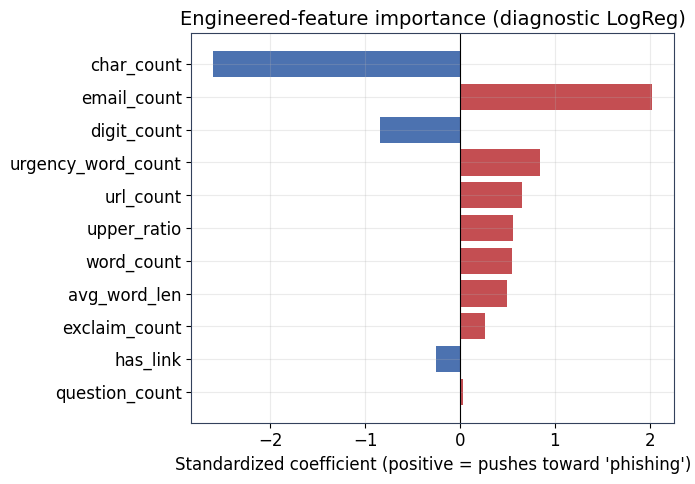

In [27]:
from sklearn.linear_model import LogisticRegression as _DiagLogReg
from sklearn.metrics import f1_score

# Diagnostic-only model: engineered features alone -> label. Never added to
# FITTED_MODELS/RESULTS, so it cannot accidentally become a 'finalist'.
_feat_diag_clf = _DiagLogReg(max_iter=2000, class_weight="balanced", random_state=SEED)
_feat_diag_clf.fit(train_feats, y_train)
_diag_val_f1 = f1_score(y_val, _feat_diag_clf.predict(val_feats))
print(f"Engineered-features-only diagnostic LogReg -- val F1: {_diag_val_f1:.4f} "
      "(sanity check: should beat a random/majority baseline by a wide margin, "
      "but is not expected to match the full text-based models.)")

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": _feat_diag_clf.coef_[0],
}).assign(abs_coef=lambda d: d["coefficient"].abs()).sort_values("abs_coef", ascending=False)

print("\nEngineered-feature importance (standardized logistic-regression coefficients):")
print(feature_importance[["feature", "coefficient"]].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in feature_importance["coefficient"]]
ax.barh(feature_importance["feature"], feature_importance["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient (positive = pushes toward 'phishing')")
ax.set_title("Engineered-feature importance (diagnostic LogReg)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "feature_importance.png", dpi=130)
plt.show()

feature_importance.to_csv(WORKING_DIR / "tables" / "feature_importance.csv", index=False)


---

[Next: Model Development, Benchmark & Ensembles →](02_model_development_and_ensembles.ipynb)